# CAFA5 Protein Function Prediction, End-to-End Pipeline Report

*A research diary in one notebook.*

**What is CAFA5?** The Critical Assessment of Functional Annotation (CAFA) is a community challenge that asks: given a protein's amino-acid sequence, predict which Gene Ontology (GO) function terms apply to it. CAFA5 is the fifth iteration; it ships ~140K training proteins, each annotated with multiple GO terms across three ontologies (Biological Process, Cellular Component, Molecular Function), and asks for per-protein, per-term confidence scores on a held-out test set.

This notebook is the long-form record of how our team approached the challenge. We pursued two complementary tracks: **sequence-only baselines** (k-mer counts and ESM2 embeddings, owned by Yu-Shan Fu) and **AlphaFold-derived protein structure graphs** trained with GNNs (owned by Benson Li). Notebook compiled 2026-05-01.

**TL;DR.** In our setup, sequence-only ESM2 reached MFO test Fmax around 0.27 / CCO around 0.21; an untuned AlphaFold-graph GCN, on the same 70/15/15 split and the same `min_term_frequency=20` vocabulary, reached MFO ~0.46 / CCO ~0.56. Late-fusing the two did not produce a test-set gain we could distinguish from seed noise. We treat both as in-our-experiments findings rather than universal claims; the relevant caveats are spelled out next to the headline numbers.

Two findings shaped the rest of this notebook, and we want to put them up front so the later sections read as the evidence behind them:

1. **Structure data appeared to substantially improve model performance, in our setup.** Going from a tuned ESM2 sequence baseline (MFO Fmax ~0.27) to a vanilla structure-graph model (MFO Fmax ~0.46) is roughly a 70% relative jump. The two numbers come from slightly different metric flavors (Section 9 spells this out); even allowing for that, the gap looks large enough that we believe the qualitative finding holds.
2. **Sequence + structure fusion did not produce a test-set improvement over structure alone.** Late-fusing the sequence model into the graph branch produced a small validation bump that did not survive on the test set. There is a non-trivial caveat about how much overlap already exists between the two branches (Section 12).

**Scope note on BPO.** Of the three GO ontologies, BPO has by far the largest filtered vocabulary (~7.7k labels at `min_term_frequency=20`) and our full BPO graph runs were memory-unstable on our partition. All formal structure-side comparisons in this report are therefore limited to **CCO** and **MFO**; BPO appears only in the dataset preview and the sequence baselines.


## 1. The CAFA5 Dataset and Its Label Space

CAFA5 ships ~140K training proteins paired with multi-label Gene Ontology annotations. After dropping rows with missing IDs, empty sequences, or non-standard amino acids, **140,569** clean proteins remain with a label matrix of shape **140,569 × 31,454**.

Two facts about that label space shaped most of the modeling decisions later:

- The matrix is sparse and **long-tailed**. Roughly 21,000 of the 31,454 GO terms appear in fewer than 20 training proteins; only a few thousand appear at least 50 times.
- GO has three top-level ontologies, Biological Process (**BPO**), Cellular Component (**CCO**), and Molecular Function (**MFO**), with quite different signal density. We trained one model per aspect.

We used a deterministic 70/15/15 train/val/test split with seed `2026`, and across the structure pipeline we filtered terms to `min_term_frequency = 20`. The choice of 20 is a pragmatic trade-off rather than a principled one: with fewer than ~20 examples the per-term Fmax is dominated by which one or two positives happen to land in val/test (essentially seed noise), while pushing the threshold above ~50 starts dropping a meaningful slice of the labels we *do* have data for. We did not sweep this threshold systematically; 20 looked reasonable on a small audit and we kept it consistent across both pipelines so the two label spaces are comparable.

**A short primer on metrics, since several variants show up in this report.**
- **Micro F1** (Section 2.1): pool TP/FP/FN across all GO terms, then compute one F1. Used by the K-mer / full-GO ESM2 baselines because that is what their tuning JSON files record.
- **Fmax**: sweep a probability threshold from 0 to 1 in 0.01 steps, take the F1 at the best threshold. Used for everything on the structure side (`fmax_from_scores`, Section 8).
- **IA-weighted Fmax**: same as Fmax but each term's contribution is multiplied by its information-content weight, so rare informative terms count more. Used for the per-namespace sequence numbers (`output/sequence_baseline_per_namespace.csv`).

These three are not directly comparable to each other; we flag the relevant statistic next to each headline number, and discuss the cross-track comparison explicitly in Section 9.

The actual loading + cleaning + multi-label encoding code (from `baselines/esm/ESM2_embedding.py` lines 30–145):



In [1]:
from pathlib import Path
from Bio import SeqIO
from sklearn.preprocessing import MultiLabelBinarizer
import numpy as np
import pandas as pd

# CAFA5 raw data lives outside the repo. We keep the unzipped Kaggle
# bundle at `~/cafa5/`; override CAFA5_DATA_DIR if yours is elsewhere.
import os
BASE_DIR  = Path(os.environ.get('CAFA5_DATA_DIR', Path.home() / 'cafa5'))
TRAIN_DIR = BASE_DIR / 'Train'
assert (TRAIN_DIR / 'train_sequences.fasta').exists(), (
    f'CAFA5 data not found at {TRAIN_DIR}. '
    f'Set CAFA5_DATA_DIR or symlink the Kaggle bundle to ~/cafa5/.'
)

# --- 1. Load FASTA sequences ---
sequences_dict = {}
for record in SeqIO.parse(TRAIN_DIR / 'train_sequences.fasta', 'fasta'):
    seq = str(record.seq).strip()
    if record.id and seq:
        sequences_dict[record.id] = seq

# --- 2. Drop sequences with non-standard amino acids ---
valid_aas = set('ACDEFGHIKLMNPQRSTVWY')
sequences_dict = {
    pid: seq
    for pid, seq in sequences_dict.items()
    if not (set(seq) - valid_aas)
}

# --- 3. Load GO term annotations and align ---
terms = pd.read_csv(TRAIN_DIR / 'train_terms.tsv', sep='\t')
terms = terms.dropna(subset=['EntryID', 'term'])
labels_dict = terms.groupby('EntryID')['term'].apply(list)

protein_ids, sequences, all_labels = [], [], []
for pid, seq in sequences_dict.items():
    if pid in labels_dict:
        protein_ids.append(pid)
        sequences.append(seq)
        all_labels.append(labels_dict[pid])

# --- 4. Multi-label encoding (full 31,454 GO term space) ---
# sparse_output=True avoids materializing a 140,569 x 31,454 dense int64
# matrix (~32 GB). The downstream code (sum(axis=...), slicing) works on
# the sparse CSR representation just as well.
from scipy.sparse import csr_matrix
mlb = MultiLabelBinarizer(sparse_output=True)
Y = mlb.fit_transform(all_labels).astype(np.int8)
Y = csr_matrix(Y)   # ensure CSR for fast row-slicing

print('Aligned proteins:', len(sequences))      # 140,569
print('Unique GO terms:', len(mlb.classes_))    # 31,454
print('Y shape:', Y.shape)                      # (140569, 31454)
print('Mean labels per protein:', Y.sum(axis=1).mean())  # ~37.8


Aligned proteins: 140569
Unique GO terms: 31454
Y shape: (140569, 31454)
Mean labels per protein: 37.83862017941367


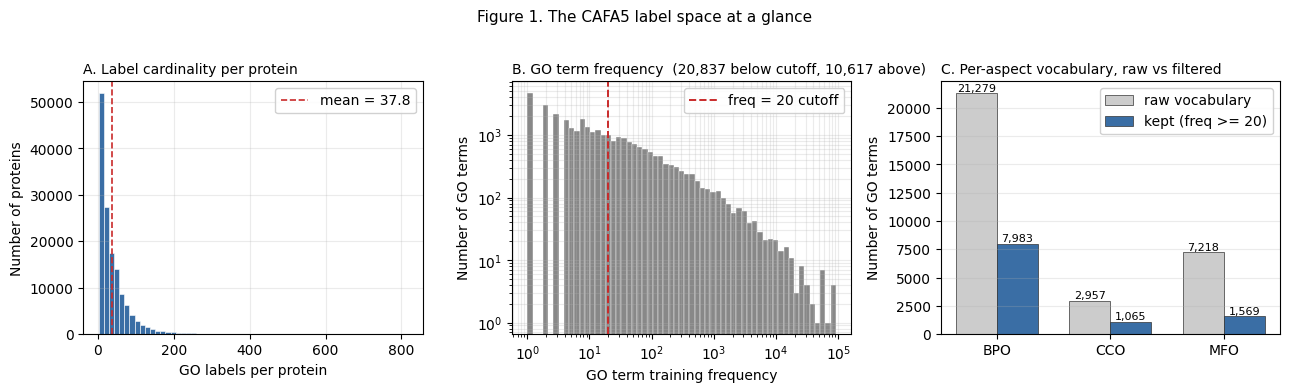

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Per-protein label cardinality (how many GO terms each protein has).
labels_per_protein = np.asarray(Y.sum(axis=1)).ravel()

# Per-term training frequency (used by the freq=20 filter later).
term_frequency = np.asarray(Y.sum(axis=0)).ravel()

# Per-aspect vocabulary sizes, before and after the freq=20 filter.
go_to_aspect = (terms[['term', 'aspect']].drop_duplicates()
                .set_index('term')['aspect'].to_dict())
aspect_of = np.array([go_to_aspect.get(t, 'unk') for t in mlb.classes_])
FREQ_CUTOFF = 20

raw_counts = {a: int((aspect_of == a).sum()) for a in ('BPO', 'CCO', 'MFO')}
kept_counts = {a: int(((aspect_of == a) & (term_frequency >= FREQ_CUTOFF)).sum())
               for a in ('BPO', 'CCO', 'MFO')}

# ----------------------------- figure -----------------------------
fig, (ax_hist, ax_freq, ax_aspect) = plt.subplots(
    1, 3, figsize=(13, 3.8))

# Panel 1: labels per protein
ax_hist.hist(labels_per_protein, bins=60, color='#3a6ea5',
             edgecolor='white', linewidth=0.4)
ax_hist.axvline(labels_per_protein.mean(), color='#c92a2a',
                ls='--', lw=1.2,
                label=f'mean = {labels_per_protein.mean():.1f}')
ax_hist.set_xlabel('GO labels per protein')
ax_hist.set_ylabel('Number of proteins')
ax_hist.set_title('A. Label cardinality per protein',
                  fontsize=10, loc='left')
ax_hist.legend(framealpha=0.9)
ax_hist.grid(True, alpha=0.25)

# Panel 2: GO term frequency (long tail), log y-axis
ax_freq.hist(term_frequency, bins=np.logspace(0, np.log10(term_frequency.max() + 1), 60),
             color='#888', edgecolor='white', linewidth=0.3)
ax_freq.axvline(FREQ_CUTOFF, color='#c92a2a', ls='--', lw=1.4,
                label=f'freq = {FREQ_CUTOFF} cutoff')
ax_freq.set_xscale('log')
ax_freq.set_yscale('log')
ax_freq.set_xlabel('GO term training frequency')
ax_freq.set_ylabel('Number of GO terms')
n_below = int((term_frequency < FREQ_CUTOFF).sum())
n_above = int((term_frequency >= FREQ_CUTOFF).sum())
ax_freq.set_title(
    f'B. GO term frequency  '
    f'({n_below:,} below cutoff, {n_above:,} above)',
    fontsize=10, loc='left')
ax_freq.legend(framealpha=0.9)
ax_freq.grid(True, alpha=0.25, which='both')

# Panel 3: per-aspect vocabulary, raw vs kept after freq>=20
aspects = ['BPO', 'CCO', 'MFO']
x = np.arange(len(aspects))
raw_vals  = [raw_counts[a]  for a in aspects]
kept_vals = [kept_counts[a] for a in aspects]
ax_aspect.bar(x - 0.18, raw_vals,  width=0.36,
              color='#cccccc', edgecolor='#333', linewidth=0.5,
              label='raw vocabulary')
ax_aspect.bar(x + 0.18, kept_vals, width=0.36,
              color='#3a6ea5', edgecolor='#333', linewidth=0.5,
              label=f'kept (freq >= {FREQ_CUTOFF})')
for xi, r, k in zip(x, raw_vals, kept_vals):
    ax_aspect.text(xi - 0.18, r + 200, f'{r:,}', ha='center', fontsize=8)
    ax_aspect.text(xi + 0.18, k + 200, f'{k:,}', ha='center', fontsize=8)
ax_aspect.set_xticks(x); ax_aspect.set_xticklabels(aspects)
ax_aspect.set_ylabel('Number of GO terms')
ax_aspect.set_title('C. Per-aspect vocabulary, raw vs filtered',
                    fontsize=10, loc='left')
ax_aspect.legend(framealpha=0.9)
ax_aspect.grid(True, axis='y', alpha=0.25)

fig.suptitle(
    'Figure 1. The CAFA5 label space at a glance',
    fontsize=11, y=1.02,
)
plt.tight_layout()
fig.savefig('figures/section1_label_space_summary.png', dpi=150, bbox_inches='tight')
plt.show()


*Figure 1. **A**, most proteins carry 30 to 50 GO labels (long-tailed with a heavy mode around 40); **B**, the GO term frequency distribution is itself long-tailed: roughly 21,000 of 31,454 terms appear in fewer than 20 training proteins, motivating the freq cutoff we use later; **C**, BPO carries far the largest vocabulary in both the raw and the filtered space, which is the operational reason we ended up reporting CCO and MFO formally and excluding BPO from the structure-side training comparison.*


## 2. Sequence Baselines: K-mer + ESM2 (Yu-Shan's pipeline)

Before touching structure, we wanted a working sequence baseline so later improvements could be measured against something honest. Yu-Shan Fu owned this track. Evaluation metric: **IA-weighted Fmax**, best F1 over thresholds, with each GO term weighted by its information content.

### 2.1 K-mer features and MLP

K-mer first because it is cheap, runs without a GPU, and gives a sanity check that the multi-label setup and the metric pipeline actually work. Each protein becomes a 400-dim k=2 (dipeptide) count vector, the vocabulary is the 20 × 20 = 400 ordered amino-acid pairs (implementation in `baselines/kmer/data_preprocessing_kmer_70.ipynb`).

**The full K-mer model and training step** (from `baselines/kmer/MLP.py`):


**Building the 400-dim k-mer feature vector** (from `baselines/kmer/data_preprocessing_kmer_70.ipynb`). For every dipeptide in the 400-pair vocabulary we count occurrences in the sequence and divide by the number of windows so the vector is length-normalized:


In [3]:
from itertools import product
import numpy as np

amino_acids = 'ACDEFGHIKLMNPQRSTVWY'
k = 2
kmer_vocab = [''.join(p) for p in product(amino_acids, repeat=k)]
kmer_to_idx = {kmer: i for i, kmer in enumerate(kmer_vocab)}

print('k =', k)
print('Number of k-mers in vocabulary:', len(kmer_vocab))   # 400


def seq_to_kmer_vector(seq, kmer_to_idx, k=2):
    """Length-normalized k-mer count vector for one protein."""
    vec = np.zeros(len(kmer_to_idx), dtype=np.float32)
    if len(seq) < k:
        return vec
    total = len(seq) - k + 1
    for i in range(total):
        kmer = seq[i:i + k]
        if kmer in kmer_to_idx:
            vec[kmer_to_idx[kmer]] += 1.0
    vec /= total
    return vec


X = np.array(
    [seq_to_kmer_vector(seq, kmer_to_idx, k=k) for seq in sequences],
    dtype=np.float32,
)
print('X shape:', X.shape)   # (140569, 400)


k = 2
Number of k-mers in vocabulary: 400


X shape: (140569, 400)


**The 70/15/15 split**, done as two sklearn calls so train_idx, val_idx, test_idx are deterministic and reusable across the K-mer and ESM2 pipelines:


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.sparse import csr_matrix

Y_sparse = csr_matrix(Y)
indices = np.arange(len(X))

# Step 1: cut test (15%)
train_val_idx, test_idx = train_test_split(
    indices, test_size=0.15, random_state=42,
)
# Step 2: cut val from the remaining 85% (15% of total = 0.15 / 0.85)
train_idx, val_idx = train_test_split(
    train_val_idx, test_size=0.15 / 0.85, random_state=42,
)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
Y_train = Y_sparse[train_idx]
Y_val   = Y_sparse[val_idx]
Y_test  = Y_sparse[test_idx]

# StandardScaler: fit on train only, apply to val/test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val   = scaler.transform(X_val).astype(np.float32)
X_test  = scaler.transform(X_test).astype(np.float32)

print('X_train:', X_train.shape, 'X_val:', X_val.shape, 'X_test:', X_test.shape)


X_train: (98397, 400) X_val: (21086, 400) X_test: (21086, 400)


In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.sparse import load_npz
from sklearn.metrics import f1_score


class ProteinKmerDataset(Dataset):
    def __init__(self, X, Y_sparse):
        self.X = X
        self.Y = Y_sparse
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, idx):
        x = torch.tensor(self.X[idx], dtype=torch.float32)
        y = torch.tensor(self.Y[idx].toarray().ravel(), dtype=torch.float32)
        return x, y


class KmerMLP(nn.Module):
    def __init__(self, input_dim, output_dim,
                 hidden1=512, hidden2=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden2, output_dim),
        )
    def forward(self, x):
        return self.net(x)


# --- per-label pos_weight to counteract class imbalance ---
label_counts = np.asarray(Y_train.sum(axis=0)).ravel().astype(np.float32)
n_train = Y_train.shape[0]
pos_weight = (n_train - label_counts) / (label_counts + 1e-6)
pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
model = KmerMLP(input_dim=X_train.shape[1], output_dim=Y_train.shape[1])
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)


**One training epoch and the threshold sweep** that gives us Fmax (from `baselines/kmer/MLP.py` lines 176–261):


In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    for X_batch, Y_batch in loader:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), Y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    probs, targets = [], []
    for X_batch, Y_batch in loader:
        logits = model(X_batch.to(device))
        probs.append(torch.sigmoid(logits).cpu().numpy())
        targets.append(Y_batch.numpy())
    return np.vstack(probs), np.vstack(targets)


def threshold_sweep(y_true, y_prob, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.55, 0.05)
    records = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.int8)
        records.append({
            'threshold': float(t),
            'micro_f1': f1_score(y_true, y_pred, average='micro', zero_division=0),
            'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        })
    best_micro = max(records, key=lambda r: r['micro_f1'])
    best_macro = max(records, key=lambda r: r['macro_f1'])
    return records, best_micro, best_macro


Training loop: 5 epochs, batch size 64, threshold sweep at the end. The full GO-space results land in `baselines/kmer/kmer_mlp_full_go_metrics.json` and the tuned per-namespace results in `baselines/kmer/kmer_tuning_summary.json`. We can load them right now:


In [7]:
import json
from pathlib import Path

kmer_full = json.loads(Path('baselines/kmer/kmer_mlp_full_go_metrics.json').read_text())
kmer_tuned = json.loads(Path('baselines/kmer/kmer_tuning_summary.json').read_text())

print('K-mer (all-GO baseline, 31,454 labels):')
print(f'  best val loss : {kmer_full["best_val_loss"]:.4f}')
print(f'  best micro F1 : {kmer_full["best_micro"]["micro_f1"]:.4f} '
      f'@ thr={kmer_full["best_micro"]["threshold"]:.2f}')
print()
print('K-mer (tuned hyperparameters):')
print(f'  best val loss : {kmer_tuned["final_best_val_loss"]:.4f}')
print(f'  best micro F1 : {kmer_tuned["final_best_micro"]["micro_f1"]:.4f} '
      f'@ thr={kmer_tuned["final_best_micro"]["threshold"]:.2f}')
print(f'  best macro F1 : {kmer_tuned["final_best_macro"]["macro_f1"]:.4f}')
print(f'  config        : lr={kmer_tuned["best_learning_rate"]} '
      f'dropout={kmer_tuned["best_dropout"]} '
      f'wd={kmer_tuned["best_weight_decay"]}')


K-mer (all-GO baseline, 31,454 labels):
  best val loss : 0.1107
  best micro F1 : 0.1019 @ thr=0.50

K-mer (tuned hyperparameters):
  best val loss : 0.0963
  best micro F1 : 0.1504 @ thr=0.75
  best macro F1 : 0.0464
  config        : lr=0.001 dropout=0.3 wd=0.0


**Hyperparameter tuning** (from `baselines/kmer/kmer_tuning.ipynb`) was done one factor at a time on a small training subset to keep the sweep fast, then the best config was retrained on full data. The grid:


In [8]:
TUNING_BASE_CONFIG = {
    'hidden1': 512,
    'hidden2': 256,
    'dropout': 0.3,
    'learning_rate': 1e-3,
    'weight_decay': 1e-5,
    'batch_size': 64,
    'num_epochs': 3,
    'patience': 3,
    'save_prefix': 'tuning_run',
}


def run_experiment(config, train_dataset, val_dataset,
                   input_dim, output_dim, criterion, device,
                   run_threshold_sweep=True):
    """Train one model with the given config, return best val metrics."""
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                              shuffle=True, num_workers=0,
                              pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_dataset, batch_size=config['batch_size'],
                              shuffle=False, num_workers=0,
                              pin_memory=torch.cuda.is_available())
    model = KmerMLP(input_dim, output_dim,
                    hidden1=config['hidden1'], hidden2=config['hidden2'],
                    dropout=config['dropout']).to(device)
    optimizer = optim.Adam(model.parameters(),
                           lr=config['learning_rate'],
                           weight_decay=config['weight_decay'])
    save_path = f"{config['save_prefix']}.pt"
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    for epoch in range(config['num_epochs']):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss   = evaluate_loss(model, val_loader, criterion, device)
        train_losses.append(train_loss); val_losses.append(val_loss)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), save_path)
    val_probs, val_targets = get_predictions(model, val_loader, device)
    records, best_micro, best_macro = threshold_sweep(val_targets, val_probs)
    return {
        'best_val_loss': best_val_loss,
        'best_micro_row': best_micro,
        'best_macro_row': best_macro,
        'model_path': save_path,
    }


In [ ]:
# --- 1. Sweep learning rate ---
learning_rates = [1e-2, 1e-3, 1e-4]
lr_results = []
for lr in learning_rates:
    config = TUNING_BASE_CONFIG.copy()
    config['learning_rate'] = lr
    config['save_prefix'] = f'kmer_lr_{lr}'
    result = run_experiment(config, train_dataset_small, val_dataset_small,
                            input_dim, output_dim, criterion, device)
    lr_results.append({'learning_rate': lr,
                       'best_val_loss': result['best_val_loss'],
                       'best_micro_f1': result['best_micro_row']['micro_f1']})
best_learning_rate = max(lr_results, key=lambda r: r['best_micro_f1'])['learning_rate']

# --- 2. Sweep dropout, holding the best lr ---
dropout_results = []
for dp in [0.0, 0.3, 0.5]:
    config = TUNING_BASE_CONFIG.copy()
    config['learning_rate'] = best_learning_rate
    config['dropout'] = dp
    config['save_prefix'] = f'kmer_dropout_{dp}'
    result = run_experiment(config, train_dataset_small, val_dataset_small,
                            input_dim, output_dim, criterion, device)
    dropout_results.append({'dropout': dp,
                            'best_val_loss': result['best_val_loss'],
                            'best_micro_f1': result['best_micro_row']['micro_f1']})
best_dropout = max(dropout_results, key=lambda r: r['best_micro_f1'])['dropout']

# --- 3. Sweep weight decay, then 4. Sweep hidden dims (same pattern) ---
# (Identical loops over weight_decay_values and hidden_configs; omitted here.)

# --- Final retrain on full data with the winning config ---
FINAL_CONFIG = TUNING_BASE_CONFIG.copy()
FINAL_CONFIG.update({
    'learning_rate': best_learning_rate,
    'dropout': best_dropout,
    'weight_decay': best_weight_decay,
    'hidden1': best_hidden1, 'hidden2': best_hidden2,
    'num_epochs': 5,
    'save_prefix': 'kmer_final_best_model',
})
final_result = run_experiment(FINAL_CONFIG, train_dataset, val_dataset,
                              input_dim, output_dim, criterion, device)


### 2.2 ESM2 embeddings

Switching to a pretrained protein language model was the obvious next move. We used Facebook's `esm2_t30_150M_UR50D` checkpoint and **mean-pooled** per-residue hidden states to a 640-d protein-level vector. The MLP head is the same shape as the K-mer MLP, but tuning preferred hidden=(1024, 512).

**The actual ESM2 embedding loop** (from `baselines/esm/ESM2_embedding.py` lines 178–248), this is the per-protein forward pass plus the chunked save strategy we used to avoid losing progress on long runs:


In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = 'facebook/esm2_t30_150M_UR50D'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()


def get_esm_embedding(seq):
    inputs = tokenizer(seq, return_tensors='pt', truncation=False)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
    last_hidden = outputs.last_hidden_state          # (1, L, 640)
    attention_mask = inputs['attention_mask']
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    summed = (last_hidden * mask).sum(dim=1)         # ignore padding
    counts = mask.sum(dim=1)
    return (summed / counts).squeeze().cpu().numpy()  # (640,)


# Chunked save every 1000 sequences so a long Savio run is recoverable
save_every = 1000
esm_embeddings = []
for i, seq in enumerate(sequences):
    esm_embeddings.append(get_esm_embedding(seq))
    if (i + 1) % save_every == 0:
        np.save(f'X_esm_chunk_{i+1}.npy', np.array(esm_embeddings))
        esm_embeddings = []
if esm_embeddings:
    np.save('X_esm_chunk_final.npy', np.array(esm_embeddings))


This embedding pass is the only really long step in the sequence track, about 6 hours on a single 1080Ti GPU, so we ran it on Savio rather than inline. The launch command was:


In [ ]:
python -u baselines/esm/ESM2_embedding.py


Once the embeddings are cached, training the ESM2 MLP is identical to the K-mer MLP (same `KmerMLP` class, just `input_dim=640`). Tuning swept `lr × dropout × weight_decay × hidden_dims` and settled on `lr=1e-3, dropout=0.3, weight_decay=0, hidden=(1024, 512)`. Loading the metrics for both models side by side:


In [9]:
esm_full = json.loads(Path('baselines/esm/esm_mlp_full_go_metrics.json').read_text())
esm_tuned = json.loads(Path('baselines/esm/esm_tuning_summary.json').read_text())

import pandas as pd
summary = pd.DataFrame([
    {
        'model': 'K-mer (full GO, 5ep)',
        'val_loss': kmer_full['best_val_loss'],
        'micro_f1': kmer_full['best_micro']['micro_f1'],
        'thr': kmer_full['best_micro']['threshold'],
    },
    {
        'model': 'K-mer (tuned)',
        'val_loss': kmer_tuned['final_best_val_loss'],
        'micro_f1': kmer_tuned['final_best_micro']['micro_f1'],
        'thr': kmer_tuned['final_best_micro']['threshold'],
    },
    {
        'model': 'ESM2 (full GO, 5ep)',
        'val_loss': esm_full['best_val_loss'],
        'micro_f1': esm_full['best_micro']['micro_f1'],
        'thr': esm_full['best_micro']['threshold'],
    },
    {
        'model': 'ESM2 (tuned)',
        'val_loss': esm_tuned['final_best_val_loss'],
        'micro_f1': esm_tuned['final_best_micro']['micro_f1'],
        'thr': esm_tuned['final_best_micro']['threshold'],
    },
])
summary.round(4)


,model,val_loss,micro_f1,thr
0,"K-mer (full GO, 5ep)",0.1107,0.1019,0.50
1,K-mer (tuned),0.0963,0.1504,0.75
2,"ESM2 (full GO, 5ep)",0.0927,0.1238,0.50
3,ESM2 (tuned),0.0782,0.2012,0.75


**ESM2 baseline training** (from `baselines/esm/MLP_ESM.ipynb`) is the same MLP head, but the input embeddings are loaded from disk (the chunked `X_esm_chunk_*.npy` files we saved on Savio), and the split indices are reused from the K-mer pipeline so both models are evaluated on exactly the same proteins:


In [ ]:
import os
import pickle
from sklearn.preprocessing import StandardScaler

DATA_DIR = 'data_processed_esm'
X_esm = np.load(os.path.join(DATA_DIR, 'X_esm.npy'))   # (140569, 640)
with open(os.path.join(DATA_DIR, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)

# Reuse the train/val/test indices from the K-mer pipeline so both
# models are compared on the same cohort.
train_idx = np.load('data_processed_kmer/train_idx.npy')
val_idx   = np.load('data_processed_kmer/val_idx.npy')
test_idx  = np.load('data_processed_kmer/test_idx.npy')

X_train_esm = X_esm[train_idx]
X_val_esm   = X_esm[val_idx]
X_test_esm  = X_esm[test_idx]

scaler_esm = StandardScaler()
X_train_esm = scaler_esm.fit_transform(X_train_esm).astype(np.float32)
X_val_esm   = scaler_esm.transform(X_val_esm).astype(np.float32)
X_test_esm  = scaler_esm.transform(X_test_esm).astype(np.float32)

# The ESM2 MLP head is exactly KmerMLP with input_dim=640.
esm_model = KmerMLP(input_dim=640,
                    output_dim=Y_train.shape[1],
                    hidden1=1024, hidden2=512, dropout=0.3).to(device)
esm_optimizer = optim.Adam(esm_model.parameters(), lr=1e-3, weight_decay=0.0)
# Same train_one_epoch / get_predictions / threshold_sweep loop as K-mer.


Per-namespace Fmax (BPO/CCO/MFO), recreated from teammate's GO-split runs (the bar chart is rendered live by the next cell):


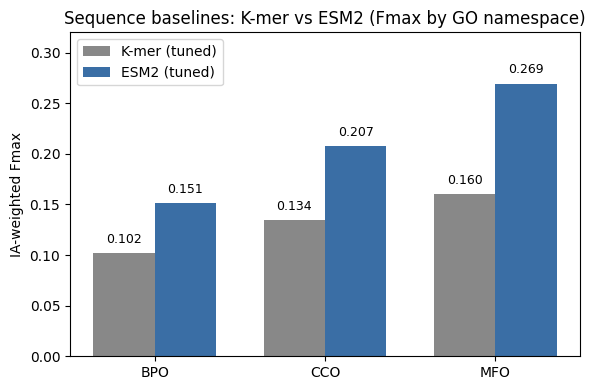

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Per-namespace IA-weighted Fmax recorded in teammate's GO-split runs
# (output cell 46 of `baselines/esm/ESM_GOsplit_70.ipynb`, archived to disk).
seq_per_ns = pd.read_csv('output/sequence_baseline_per_namespace.csv')
seq_per_ns_pivot = seq_per_ns.pivot(index='namespace', columns='feature',
                                    values='ia_fmax').reindex(['BPO', 'CCO', 'MFO'])

x = np.arange(len(seq_per_ns_pivot))
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - 0.18, seq_per_ns_pivot['K-mer'], width=0.36,
       label='K-mer (tuned)', color='#888')
ax.bar(x + 0.18, seq_per_ns_pivot['ESM2'],  width=0.36,
       label='ESM2 (tuned)',  color='#3a6ea5')
for xi, k, e in zip(x, seq_per_ns_pivot['K-mer'], seq_per_ns_pivot['ESM2']):
    ax.text(xi - 0.18, k + 0.01, f'{k:.3f}', ha='center', fontsize=9)
    ax.text(xi + 0.18, e + 0.01, f'{e:.3f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(seq_per_ns_pivot.index)
ax.set_ylabel('IA-weighted Fmax')
ax.set_ylim(0, 0.32)
ax.set_title('Sequence baselines: K-mer vs ESM2 (Fmax by GO namespace)')
ax.legend(loc='upper left')
plt.tight_layout(); fig.savefig('figures/section2_kmer_vs_esm2_bars.png', dpi=150, bbox_inches='tight')
plt.show()


**Reading the result.** ESM2 beats K-mer by ~1.4× on BPO/CCO and **1.8× on MFO**, but the absolute numbers stay below 0.30 Fmax. A protein-level mean-pool of a sequence model is throwing away too much of the structural and contextual signal that GO labels actually depend on. We hit a clear ceiling and decided to bring in real structure.

Plotting the validation-loss trajectory across the 5 training epochs for both models from the JSON history makes the gap concrete:


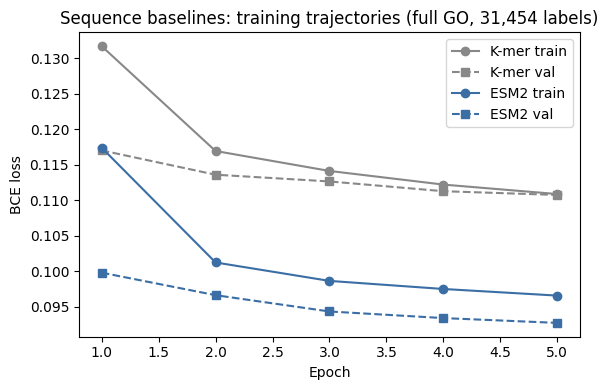

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))
epochs = list(range(1, 6))
ax.plot(epochs, kmer_full['train_losses'], 'o-', color='#888', label='K-mer train')
ax.plot(epochs, kmer_full['val_losses'],   's--', color='#888', label='K-mer val')
ax.plot(epochs, esm_full['train_losses'],  'o-', color='#3a6ea5', label='ESM2 train')
ax.plot(epochs, esm_full['val_losses'],    's--', color='#3a6ea5', label='ESM2 val')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE loss')
ax.set_title('Sequence baselines: training trajectories (full GO, 31,454 labels)')
ax.legend()
plt.tight_layout(); fig.savefig('figures/section2_sequence_loss_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.3 Frequency filter and per-namespace BPO / CCO / MFO training

The per-namespace numbers in the comparison figure above come from a **separate, more carefully preprocessed** training run, not the 31,454-label full-GO model from section 2.1. Two preprocessing steps happen before that namespace-specific training:

1. **Frequency filter (`min_term_frequency = 20`).** Drop every GO term that appears in fewer than 20 training proteins. Almost half the vocabulary disappears (we keep about 10,617 of 31,454 labels) but almost none of the labels we actually have signal for go away. This is the same `min_term_frequency = 20` we use on the structure side, by design, so both pipelines train against label spaces of comparable scale.
2. **Namespace split.** Project the filtered label matrix into three sub-matrices, one per ontology, using each GO term's `aspect` annotation. Protein splits stay identical across the three models.

**Step 1, the frequency filter** (from `baselines/kmer/kmer_GOsplit_70.ipynb` cell 6 / `baselines/esm/ESM_GOsplit_70.ipynb` cell equivalent). We count each labels occurrences across the full label matrix (train + val + test combined) and keep only labels at or above the threshold. Counting on the combined matrix is what the teammate pipeline actually does; the difference vs counting on train alone is negligible at freq>=20 because almost any label with >=20 examples in the combined set also has >=20 in train (which is 70%):


In [12]:
import scipy.sparse

FREQ_THRESHOLD = 20

# Count each label occurrences across the full label matrix
# (train + val + test, matching the teammate pipeline).
Y_full = scipy.sparse.vstack([Y_train, Y_val, Y_test])
label_counts = np.asarray(Y_full.sum(axis=0)).ravel().astype(np.float32)

keep_idx = np.where(label_counts >= FREQ_THRESHOLD)[0]
removed_idx = np.where(label_counts <  FREQ_THRESHOLD)[0]

Y_train_filtered = Y_train[:, keep_idx]
Y_val_filtered   = Y_val[:,   keep_idx]
Y_test_filtered  = Y_test[:,  keep_idx]

go_terms_filtered = [mlb.classes_[i] for i in keep_idx]

print(f'Original GO terms : {Y_train.shape[1]:,}')
print(f'Kept (freq >= {FREQ_THRESHOLD}): {len(keep_idx):,}')
print(f'Removed           : {len(removed_idx):,} '
      f'({100 * len(removed_idx) / Y_train.shape[1]:.1f}%)')
print(f'Y_train shape     : {Y_train_filtered.shape}')


Original GO terms : 31,454
Kept (freq >= 20): 10,617
Removed           : 20,837 (66.2%)
Y_train shape     : (98397, 10617)


**Step 2 then operates on the filtered matrix.** From here, `Y_train_filtered` (shape `(98397, 10617)`) is split column-wise into per-namespace label sub-matrices, exactly the same way as before, but now operating on a smaller and cleaner label space. The full-GO baseline numbers from section 2.1 (val_loss 0.0963, micro F1 0.150) used the **unfiltered** 31,454-label space; the per-namespace bar chart numbers above use this **filtered** space. That is why the two sets of numbers are not directly comparable, they come from different label vocabularies.


In [13]:
import pandas as pd

TERMS_PATH = TRAIN_DIR / 'train_terms.tsv'   # path defined back in section 1
terms_df = pd.read_csv(TERMS_PATH, sep='\t')

# Map each GO term to its ontology aspect (BPO / CCO / MFO)
go_to_aspect = (
    terms_df[['term', 'aspect']]
    .drop_duplicates()
    .set_index('term')['aspect']
    .to_dict()
)

# Use the *filtered* vocabulary, not the full 31,454-term mlb.classes_.
bpo_idx = [i for i, g in enumerate(go_terms_filtered) if go_to_aspect.get(g) == 'BPO']
cco_idx = [i for i, g in enumerate(go_terms_filtered) if go_to_aspect.get(g) == 'CCO']
mfo_idx = [i for i, g in enumerate(go_terms_filtered) if go_to_aspect.get(g) == 'MFO']

print('After freq>=20 filter:')
print(f'  BPO labels: {len(bpo_idx):>5}')
print(f'  CCO labels: {len(cco_idx):>5}')
print(f'  MFO labels: {len(mfo_idx):>5}')
print(f'  Total      : {len(bpo_idx) + len(cco_idx) + len(mfo_idx):>5} '
      f'(should match kept count: {len(go_terms_filtered)})')

# Slice the *filtered* label matrices into namespace-specific Y matrices.
Y_train_BPO = Y_train_filtered[:, bpo_idx]
Y_val_BPO   = Y_val_filtered[:,   bpo_idx]
Y_test_BPO  = Y_test_filtered[:,  bpo_idx]
Y_train_CCO = Y_train_filtered[:, cco_idx]
Y_val_CCO   = Y_val_filtered[:,   cco_idx]
Y_test_CCO  = Y_test_filtered[:,  cco_idx]
Y_train_MFO = Y_train_filtered[:, mfo_idx]
Y_val_MFO   = Y_val_filtered[:,   mfo_idx]
Y_test_MFO  = Y_test_filtered[:,  mfo_idx]


After freq>=20 filter:
  BPO labels:  7983
  CCO labels:  1065
  MFO labels:  1569
  Total      : 10617 (should match kept count: 10617)


**Freq=20 filter, before-and-after.** Two facts go into the same figure below:

1. *What the filter removes from the vocabulary.* The bar at the top is the label space at each stage, broken into the kept BPO / CCO / MFO slices and the dropped tail.
2. *How the filter changes the headline metric.* The bottom panel puts each tuned model's no-filter score (single number on the full 31,454-label space) next to its with-filter scores (one per namespace, on the smaller filtered label spaces).

Important caveat that the figure spells out in its labels: the no-filter and with-filter metrics are not the same statistic. The no-filter score is **micro F1 across all 31,454 labels** at the best threshold (from `baselines/kmer/kmer_tuning_summary.json` / `baselines/esm/esm_tuning_summary.json`). The with-filter scores are **IA-weighted Fmax per namespace** (from `output/sequence_baseline_per_namespace.csv`). Both are valid report-level numbers; we cannot directly subtract them.


/tmp/ipykernel_1480922/3075604943.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


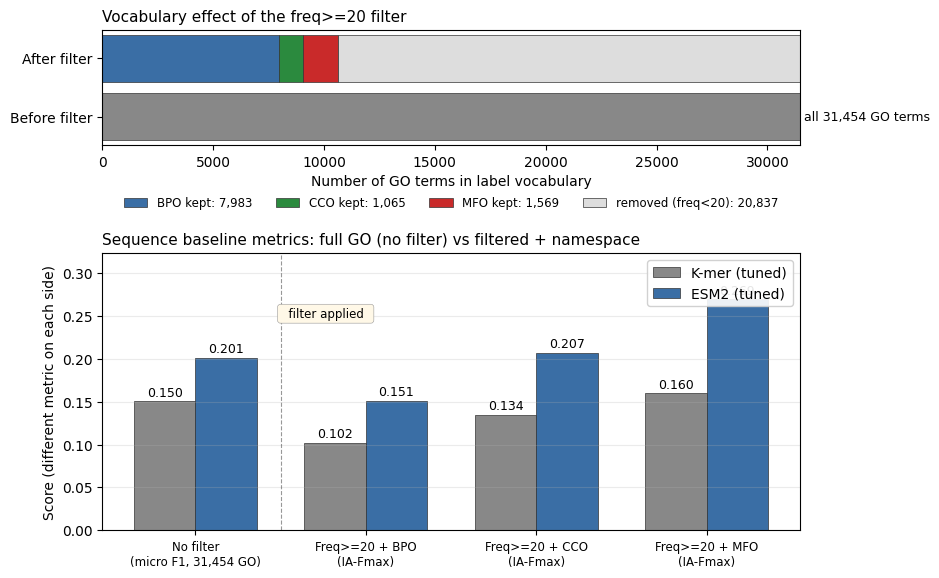

In [14]:
import matplotlib.pyplot as plt
import numpy as np

ns_pivot = seq_per_ns.pivot(index='namespace', columns='feature',
                            values='ia_fmax').reindex(['BPO', 'CCO', 'MFO'])

fig, (ax_vocab, ax_metric) = plt.subplots(
    2, 1, figsize=(9, 6.5),
    gridspec_kw={'height_ratios': [1, 2.4], 'hspace': 0.55},
)

# ===== TOP: vocabulary composition before vs after the filter =====
total_terms = int(len(keep_idx) + len(removed_idx))
kept_bpo, kept_cco, kept_mfo = len(bpo_idx), len(cco_idx), len(mfo_idx)

# 'Before filter' bar: one solid block at the full vocab.
ax_vocab.barh(['Before filter'], [total_terms],
              color='#888', edgecolor='#333', linewidth=0.5)
ax_vocab.text(total_terms, 0,
              f' all {total_terms:,} GO terms',
              va='center', ha='left', fontsize=9)

# 'After filter' bar: stacked BPO + CCO + MFO + removed.
left = 0
for name, count, color in [
    ('BPO kept',     kept_bpo,  '#3a6ea5'),
    ('CCO kept',     kept_cco,  '#2b8a3e'),
    ('MFO kept',     kept_mfo,  '#c92a2a'),
    ('removed (freq<20)', int(len(removed_idx)), '#dddddd'),
]:
    ax_vocab.barh(['After filter'], [count], left=[left],
                  color=color, edgecolor='#333', linewidth=0.5,
                  label=f'{name}: {count:,}')
    left += count
ax_vocab.set_xlim(0, total_terms)
ax_vocab.set_xlabel('Number of GO terms in label vocabulary')
ax_vocab.set_title('Vocabulary effect of the freq>=20 filter',
                   fontsize=11, loc='left')
ax_vocab.legend(loc='lower center', bbox_to_anchor=(0.5, -0.65),
                ncol=4, fontsize=8.5, frameon=False)

# ===== BOTTOM: per-model metric comparison =====
groups = [
    'No filter\n(micro F1, 31,454 GO)',
    'Freq>=20 + BPO\n(IA-Fmax)',
    'Freq>=20 + CCO\n(IA-Fmax)',
    'Freq>=20 + MFO\n(IA-Fmax)',
]
kmer_vals = [
    kmer_tuned['final_best_micro']['micro_f1'],
    float(ns_pivot.loc['BPO', 'K-mer']),
    float(ns_pivot.loc['CCO', 'K-mer']),
    float(ns_pivot.loc['MFO', 'K-mer']),
]
esm_vals = [
    esm_tuned['final_best_micro']['micro_f1'],
    float(ns_pivot.loc['BPO', 'ESM2']),
    float(ns_pivot.loc['CCO', 'ESM2']),
    float(ns_pivot.loc['MFO', 'ESM2']),
]

x = np.arange(len(groups))
ax_metric.bar(x - 0.18, kmer_vals, width=0.36,
              color='#888', edgecolor='#333', linewidth=0.5,
              label='K-mer (tuned)')
ax_metric.bar(x + 0.18, esm_vals, width=0.36,
              color='#3a6ea5', edgecolor='#333', linewidth=0.5,
              label='ESM2 (tuned)')
for xi, k, e in zip(x, kmer_vals, esm_vals):
    ax_metric.text(xi - 0.18, k + 0.006, f'{k:.3f}',
                   ha='center', fontsize=9)
    ax_metric.text(xi + 0.18, e + 0.006, f'{e:.3f}',
                   ha='center', fontsize=9)

# Vertical divider between the no-filter group and the filtered groups.
ax_metric.axvline(0.5, color='#333', ls='--', lw=0.8, alpha=0.5)
ax_metric.text(0.5, ax_metric.get_ylim()[1] * 0.92,
               '  filter applied  ',
               ha='left', va='top', fontsize=8.5,
               bbox=dict(boxstyle='round,pad=0.25',
                         fc='#fff8e7', ec='#999', lw=0.4))

ax_metric.set_xticks(x)
ax_metric.set_xticklabels(groups, fontsize=8.5)
ax_metric.set_ylabel('Score (different metric on each side)')
ax_metric.set_ylim(0, max(max(kmer_vals), max(esm_vals)) * 1.2)
ax_metric.set_title(
    'Sequence baseline metrics: full GO (no filter) vs filtered + namespace',
    fontsize=11, loc='left',
)
ax_metric.legend(loc='upper right', framealpha=0.9)
ax_metric.grid(True, axis='y', alpha=0.25)

plt.tight_layout()
fig.savefig('figures/section2_freq_filter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


**What the figure says.** The filter cuts the vocabulary roughly in two-thirds (about 21,000 of 31,454 terms get dropped because they appear in fewer than 20 training proteins), and the kept slice splits unevenly across ontologies (BPO is by far the largest). On the metric side, ESM2 stays the stronger model on every panel, but the per-namespace breakdown also shows where the model is most and least confident: MFO Fmax (0.27) > CCO Fmax (0.21) > BPO Fmax (0.15) for ESM2, and the same ordering for K-mer just at lower absolute levels. That MFO ranking is the one that matters when we later compare the structure track to it, our structure runs use the same `min_term_frequency = 20` threshold, so they're evaluating against label spaces of comparable scale to the right-hand bars.


Each namespace gets its own `pos_weight` tensor (label imbalance is different in each ontology) and its own MLP. The training step is the `train_one_epoch` we already defined; the only change is the loss criterion built from per-namespace label counts:


In [ ]:
def build_namespace_criterion(Y_train_namespace, device):
    """Per-namespace BCE-with-logits loss with class-imbalance pos_weight."""
    label_counts_ns = np.asarray(Y_train_namespace.sum(axis=0)).ravel().astype(np.float32)
    n_train = Y_train_namespace.shape[0]
    pos_weight = (n_train - label_counts_ns) / (label_counts_ns + 1e-6)
    pos_weight = np.clip(pos_weight, 1.0, 100.0)
    pos_weight_tensor = torch.tensor(pos_weight, dtype=torch.float32, device=device)
    return nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)


namespace_results = {}
for aspect, (Y_tr, Y_va, Y_te, num_labels) in {
    'BPO': (Y_train_BPO, Y_val_BPO, Y_test_BPO, len(bpo_idx)),
    'CCO': (Y_train_CCO, Y_val_CCO, Y_test_CCO, len(cco_idx)),
    'MFO': (Y_train_MFO, Y_val_MFO, Y_test_MFO, len(mfo_idx)),
}.items():
    print(f'=== Training {aspect} model ({num_labels} labels) ===')
    criterion_ns = build_namespace_criterion(Y_tr, device)
    model_ns = KmerMLP(input_dim=X_train.shape[1], output_dim=num_labels,
                       hidden1=1024, hidden2=512, dropout=0.3).to(device)
    optimizer_ns = optim.Adam(model_ns.parameters(), lr=1e-3, weight_decay=0.0)

    train_loader_ns = DataLoader(ProteinKmerDataset(X_train, Y_tr),
                                 batch_size=64, shuffle=True)
    val_loader_ns   = DataLoader(ProteinKmerDataset(X_val, Y_va),
                                 batch_size=64, shuffle=False)

    for epoch in range(5):
        train_loss = train_one_epoch(model_ns, train_loader_ns, criterion_ns,
                                     optimizer_ns, device)
    val_probs, val_targets = get_predictions(model_ns, val_loader_ns, device)
    _, best_micro, best_macro = threshold_sweep(val_targets, val_probs)
    namespace_results[aspect] = {
        'val_micro_f1': best_micro['micro_f1'],
        'val_macro_f1': best_macro['macro_f1'],
        'best_threshold': best_micro['threshold'],
    }
    torch.save(model_ns.state_dict(), f'kmer_{aspect}_final.pt')

pd.DataFrame(namespace_results).T.round(4)


**Where this leaves the sequence track.** With three namespace-specific ESM2 MLPs at hand, the per-namespace test Fmax settled at BPO 0.150, CCO 0.209, MFO 0.270, the numbers we plotted in the bar chart in section 2.2. They are reasonable first results, but they are also a clear ceiling: a protein-level mean-pool of a sequence model has lost too much of the signal that GO actually depends on. We need a representation that can see 3D structure.


## 3. The Pivot: Add AlphaFold Structure

Sequence embeddings ignore the 3D fold of a protein, but a lot of what GO is asking us to predict is structural in nature. *Where* a residue sits in the binding pocket, *which* residues are spatially adjacent across a long sequence gap, *how confident* we are about each part of the fold, none of that is in the ESM2 mean-pool.

AlphaFold gives us all of it. For nearly every UniProt entry in CAFA5 there is a predicted structure (PDB) with per-residue pLDDT confidence, plus a Predicted Aligned Error (PAE) matrix. The next five sections are the structure pipeline: download, feature extraction, graph cache, training, tuning.


## 4. AlphaFold Download Pipeline

The downloader is `src/cafa5_alphafold_pipeline.py`. It is a resumable, throttled, thread-pooled walker over UniProt accessions that hits `https://alphafold.ebi.ac.uk/api/prediction/<accession>`, parses the metadata, and downloads the PDB + PAE JSON for each fragment.

The two pieces worth showing are the throttled HTTP fetch and the atomic file write. Running ~140K downloads over a network requires rate limiting and crash safety; both fit in ~70 lines:


In [15]:
import threading, time
import requests
from requests.adapters import HTTPAdapter
from pathlib import Path

ALPHAFOLD_API_BASE = 'https://alphafold.ebi.ac.uk/api/prediction'


class RequestThrottle:
    """Global token bucket: every request waits its slot."""
    def __init__(self, request_delay):
        self.request_delay = request_delay
        self._lock = threading.Lock()
        self._next_allowed = 0.0
    def wait(self):
        with self._lock:
            now = time.monotonic()
            sleep_for = max(0.0, self._next_allowed - now)
            self._next_allowed = max(now, self._next_allowed) + self.request_delay
        if sleep_for > 0:
            time.sleep(sleep_for)


class AlphaFoldClient:
    def __init__(self, request_delay=0.5):
        self._tl = threading.local()
        self._throttle = RequestThrottle(request_delay)

    def _session(self):
        s = getattr(self._tl, 'session', None)
        if s is None:
            s = requests.Session()
            adapter = HTTPAdapter(max_retries=4)
            s.mount('https://', adapter); s.mount('http://', adapter)
            self._tl.session = s
        return s

    def fetch_metadata(self, entry_id):
        accession = entry_id.strip().upper()
        url = f'{ALPHAFOLD_API_BASE}/{accession}'
        self._throttle.wait()
        response = self._session().get(url, timeout=30)
        if response.status_code == 404:
            return None  # Protein not in AlphaFold DB
        response.raise_for_status()
        return response.json()

    def download_to_path(self, url, dest_path):
        """Atomic write via .part suffix so an interrupted download
        never leaves a half-written file in place."""
        self._throttle.wait()
        response = self._session().get(url, stream=True, timeout=(10, 60))
        response.raise_for_status()
        tmp = dest_path.with_suffix(dest_path.suffix + '.part')
        with tmp.open('wb') as h:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk: h.write(chunk)
        tmp.replace(dest_path)


We ran the full download with 4 worker threads and a 0.5 s delay per request. At that pace ~140K proteins took roughly a day to mirror. **Coverage came in at ~86.4%**, 122,925 of 142,246 proteins had a usable AlphaFold structure. Invocation:


In [ ]:
python src/cafa5_alphafold_pipeline.py \
    --train-taxonomy data/kaggle_cafa5/extracted/Train/train_taxonomy.tsv \
    --train-sequences data/kaggle_cafa5/extracted/Train/train_sequences.fasta \
    --train-terms data/kaggle_cafa5/extracted/Train/train_terms.tsv \
    --output-dir outputs/cafa5_af_full \
    --workers 4 \
    --request-delay 0.5 \
    --resume


## 5. Structure Feature Extraction

`src/alphafold_feature_extractor.py` converts downloaded PDB/PAE files into three parquet tables. The extractor is dependency-light (no Biopython, no DSSP) so it runs in the existing project env.

**The PDB parser**, we only need Cα atoms with their pLDDT, which is encoded in column 60–66 of the ATOM record. Pure string slicing is fast and avoids a heavy dependency:


In [16]:
from dataclasses import dataclass
from pathlib import Path

AA3_TO_AA1 = {
    'ALA': 'A', 'ARG': 'R', 'ASN': 'N', 'ASP': 'D', 'CYS': 'C',
    'GLN': 'Q', 'GLU': 'E', 'GLY': 'G', 'HIS': 'H', 'ILE': 'I',
    'LEU': 'L', 'LYS': 'K', 'MET': 'M', 'PHE': 'F', 'PRO': 'P',
    'SER': 'S', 'THR': 'T', 'TRP': 'W', 'TYR': 'Y', 'VAL': 'V',
    'UNK': 'X',
}


@dataclass(frozen=True)
class ResidueRecord:
    residue_index: int
    chain_id: str
    residue_number: int
    residue_name1: str
    x: float
    y: float
    z: float
    plddt: float


def parse_pdb_ca_residues(path: Path):
    residues = []
    for line in path.read_text(encoding='utf-8').splitlines():
        if not line.startswith('ATOM'):
            continue
        if line[12:16].strip() != 'CA':
            continue
        residues.append(ResidueRecord(
            residue_index=len(residues) + 1,
            chain_id=line[21].strip() or 'A',
            residue_number=int(line[22:26].strip()),
            residue_name1=AA3_TO_AA1.get(line[17:20].strip().upper(), 'X'),
            x=float(line[30:38].strip()),
            y=float(line[38:46].strip()),
            z=float(line[46:54].strip()),
            plddt=float(line[60:66].strip()),
        ))
    return residues


def classify_plddt(plddt):
    if plddt < 50: return 'very_low'
    if plddt < 70: return 'low'
    if plddt < 90: return 'confident'
    return 'very_high'


**The contact graph** is built from the Cα coordinates. We keep two thresholds: 10 Å for the canonical contact graph, 8 Å for a strict variant we could swap in later for ablation:


In [17]:
import math


def build_contact_edges(residues, contact_threshold=10.0,
                        strict_threshold=8.0, pae_matrix=None):
    """Yield (i, j, distance, contact_type) for every Ca-Ca pair under threshold."""
    edges = []
    n = len(residues)
    for i in range(n):
        ri = residues[i]
        for j in range(i + 1, n):
            rj = residues[j]
            dx = ri.x - rj.x
            dy = ri.y - rj.y
            dz = ri.z - rj.z
            d = math.sqrt(dx * dx + dy * dy + dz * dz)
            if d > contact_threshold:
                continue
            contact_type = 'strict' if d <= strict_threshold else 'normal'
            pae = pae_matrix[i][j] if pae_matrix else None
            edges.append((i, j, d, pae, contact_type))
    return edges


def radius_of_gyration(residues):
    cx = sum(r.x for r in residues) / len(residues)
    cy = sum(r.y for r in residues) / len(residues)
    cz = sum(r.z for r in residues) / len(residues)
    return math.sqrt(sum(
        (r.x - cx) ** 2 + (r.y - cy) ** 2 + (r.z - cz) ** 2
        for r in residues
    ) / len(residues))


Three parquet tables come out: `fragment_features.parquet` (per-fragment summaries), `residue_features.parquet` (per-residue node features), and `contact_graph_edges.parquet` (per-edge connectivity). Visualizing one example fragment (Q8IXT2): the contact map shows the diagonal band of sequential neighbors plus the off-diagonal blocks of long-range structural contacts:

![Contact map example](figures/feature_extraction_contact_map.png)

The CLI invocation is:


In [ ]:
python src/alphafold_feature_extractor.py \
    --training-index outputs/cafa5_af_full/manifests/training_index.parquet \
    --fragment-manifest outputs/cafa5_af_full/manifests/alphafold_fragments.parquet \
    --output-dir outputs/cafa5_af_full/features \
    --contact-threshold 10.0 \
    --strict-contact-threshold 8.0 \
    --workers 8 \
    --resume


## 6. Building the Graph Cache

`src/cafa_graph_dataset.py` is the heavy lifter, it assembles per-protein PyTorch Geometric and DGL graph objects from the parquet tables. Every cached graph has the same multimodal schema with reserved slots for modalities we add later (DSSP/SASA, ESM2 residue embeddings).

Schema constants from `src/cafa_graph_dataset.py`:


In [18]:
BASE_FEATURE_DIM = 32       # AA one-hot + pLDDT bin + degree + PAE stats + frag info
DSSP_SASA_DIM = 10          # reserved (zero-filled until DSSP cache ready)
ESM2_DIM = 640              # reserved (zero-filled until ESM2 residue cache ready)
NODE_FEATURE_DIM = BASE_FEATURE_DIM + DSSP_SASA_DIM + ESM2_DIM   # 682
EDGE_ATTR_DIM = 6           # distance + PAE mean/min/max + contact-type flags
GRAPH_FEAT_DIM = 13         # protein-level summary
MODALITY_MASK_DIM = 3       # which feature blocks are real

BASE_SLICE = slice(0, BASE_FEATURE_DIM)
DSSP_SASA_SLICE = slice(BASE_FEATURE_DIM, BASE_FEATURE_DIM + DSSP_SASA_DIM)
ESM2_SLICE = slice(BASE_FEATURE_DIM + DSSP_SASA_DIM, NODE_FEATURE_DIM)


**The 32-d base node feature** (`make_base_feature` from `src/cafa_graph_dataset.py`). Each residue is encoded as: 21-d amino-acid one-hot (positions 0–20), pLDDT scalar + 4 pLDDT bin one-hots (21–25), PAE row stats, mean / min / 90th percentile (26–28), normal and strict contact degrees (29–30), and the residue's normalized sequence position (31). The full 682-d node tensor is this 32-d block concatenated with the 10-d DSSP/SASA slot and the 640-d ESM2 slot, both zero-filled at build time and overlaid later by the cache loader:


In [19]:
AA_ORDER = ['A', 'R', 'N', 'D', 'C', 'Q', 'E', 'G', 'H', 'I',
            'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V', 'X']
AA_TO_INDEX = {aa: i for i, aa in enumerate(AA_ORDER)}


def make_base_feature(residue_row, sequence_length,
                      contact_degree, strict_contact_degree):
    feature = [0.0] * NODE_FEATURE_DIM   # 682, all zeros at start
    aa = residue_row.get('residue_name1') or 'X'
    feature[AA_TO_INDEX.get(aa, AA_TO_INDEX['X'])] = 1.0
    feature[21] = float(residue_row.get('plddt') or 0.0)
    feature[22] = 1.0 if residue_row.get('is_plddt_very_low')  else 0.0
    feature[23] = 1.0 if residue_row.get('is_plddt_low')        else 0.0
    feature[24] = 1.0 if residue_row.get('is_plddt_confident')  else 0.0
    feature[25] = 1.0 if residue_row.get('is_plddt_very_high')  else 0.0
    feature[26] = float(residue_row.get('pae_row_mean') or 0.0)
    feature[27] = float(residue_row.get('pae_row_min')  or 0.0)
    feature[28] = float(residue_row.get('pae_row_p90')  or 0.0)
    feature[29] = float(contact_degree)
    feature[30] = float(strict_contact_degree)
    cafa_index = residue_row.get('cafa_residue_index')
    if cafa_index is not None and sequence_length > 0:
        feature[31] = float(cafa_index) / float(sequence_length)
    return feature  # positions 32..681 are reserved (filled later)


**Building one graph record** (the core of `build_protein_graph_record`). Given a protein's residue rows and edge rows from the parquet tables, we construct a node feature matrix `x`, a directed edge_index by duplicating each undirected edge in both directions, a 6-d edge attribute vector, and a 13-d protein-level summary vector `graph_feat`:


In [20]:
def build_graph_record(residue_rows, edge_rows, training_row):
    sequence_length = int(training_row.get('sequence_length') or 0)
    selected = [r for r in residue_rows
                if r.get('cafa_residue_index') is not None]
    selected.sort(key=lambda r: int(r['cafa_residue_index']))

    # Map cafa residue index -> position in the node tensor
    cafa_to_node = {int(r['cafa_residue_index']): i
                    for i, r in enumerate(selected)}

    # Walk edges, count contact degrees per node, build edge attributes
    contact_deg = [0] * len(selected)
    strict_deg  = [0] * len(selected)
    edge_index = [[], []]
    edge_attr  = []
    for e in edge_rows:
        src = cafa_to_node.get(int(e['source_cafa_residue_index']))
        dst = cafa_to_node.get(int(e['target_cafa_residue_index']))
        if src is None or dst is None or src == dst:
            continue
        contact_deg[src] += 1; contact_deg[dst] += 1
        if e.get('is_strict_contact'):
            strict_deg[src] += 1; strict_deg[dst] += 1
        attr = [
            float(e.get('distance_ca')   or 0.0),
            float(e.get('seq_separation') or 0.0),
            float(e.get('pae_mean_pair') or 0.0),
            1.0 if e.get('is_sequential_neighbor') else 0.0,
            1.0 if e.get('is_short_range_sequence') else 0.0,
            1.0 if e.get('is_strict_contact')      else 0.0,
        ]
        # Bidirectional: undirected edges added in both directions
        edge_index[0].extend([src, dst])
        edge_index[1].extend([dst, src])
        edge_attr.extend([attr, attr.copy()])

    # Node features (with degrees that we just computed)
    x = [
        make_base_feature(r, sequence_length, contact_deg[i], strict_deg[i])
        for i, r in enumerate(selected)
    ]

    # 13-d protein-level summary: residue count, fragment count,
    # mean/median pLDDT, fraction in each of 4 pLDDT bins,
    # mean contact degree, graph density, mean PAE,
    # 90th-percentile of per-residue pae_row_p90, radius of gyration.
    plddt = [r['plddt'] for r in selected]
    n = len(selected)
    possible_pairs = n * (n - 1) / 2
    graph_feat = [
        float(n),
        float(len({r['model_entity_id'] for r in selected})),
        np.mean(plddt), np.median(plddt),
        sum(p < 50  for p in plddt) / n,
        sum(50 <= p < 70 for p in plddt) / n,
        sum(70 <= p < 90 for p in plddt) / n,
        sum(p >= 90 for p in plddt) / n,
        np.mean(contact_deg),
        (len(edge_attr) // 2) / possible_pairs if possible_pairs else 0.0,
        np.mean([r.get('pae_row_mean', 0.0) for r in selected]),
        np.percentile([r.get('pae_row_p90', 0.0) for r in selected], 90),
        radius_of_gyration_from_pos([(r['x'], r['y'], r['z']) for r in selected]),
    ]
    return {'x': x, 'edge_index': edge_index, 'edge_attr': edge_attr,
            'graph_feat': graph_feat, 'labels': training_row['go_terms']}


**Wrapping a payload as a PyG `Data` object** (`CafaPyGDataset.__getitem__`). Each graph cache `.pt` is loaded, the modality caches are overlaid, the labels are encoded into a binary vector against the per-aspect vocab, and a PyG `Data` object with the standard fields plus our metadata is returned:


In [ ]:
from torch_geometric.data import Data as PygData
import torch


class CafaPyGDataset(_BaseCafaGraphDataset):
    def __getitem__(self, index):
        payload = self._load_payload(self.entries[index])
        return PygData(
            x=payload['x'],                               # (N, 682)
            pos=payload['pos'],                           # (N, 3)
            edge_index=payload['edge_index'],             # (2, E)
            edge_attr=payload['edge_attr'],               # (E, 6)
            y=payload['y'],                               # (vocab,) binary
            graph_feat=payload['graph_feat'],             # (13,)
            cafa_residue_index=payload['cafa_residue_index'],
            residue_index=payload['residue_index'],
            fragment_id=payload['fragment_id'],
            node_modality_mask=payload['node_modality_mask'],  # (N, 3)
            entry_id=payload['entry_id'],
            taxonomy_id=payload['taxonomy_id'],
            fragment_ids=payload['fragment_ids'],
        )


**Filling the reserved ESM2 slot at load time** (`_BaseCafaGraphDataset._apply_esm2_cache`). The base graph cache stores zeros in the 640-d ESM2 region; whenever a per-protein cache exists at `modality_cache/esm2/{entry_id}.pt`, those embeddings are overlaid into the slot and the modality mask is flipped on. The same pattern is used for DSSP/SASA. This is what makes `--disable-esm2` ablations clean, a single CLI flag tells the dataset to skip the overlay:


In [21]:
def _apply_esm2_cache(self, payload):
    if not self.use_esm2:
        return                                         # ablation: leave zeros
    cache_path = self.esm2_cache_dir / f"{payload['entry_id']}.pt"
    if not cache_path.exists():
        return                                         # protein has no cached ESM2

    cache = torch.load(cache_path, map_location='cpu', weights_only=False)
    residue_embedding = cache['residue_embedding']     # (M, 640)
    cafa_indices = cache['cafa_residue_index'].tolist()
    if residue_embedding.shape[1] != ESM2_DIM:
        raise ValueError(f'ESM2 width {residue_embedding.shape[1]} != {ESM2_DIM}')

    cache_index = {int(idx): row for row, idx in enumerate(cafa_indices)}
    for row, cafa_index in enumerate(payload['cafa_residue_index'].tolist()):
        cache_row = cache_index.get(int(cafa_index))
        if cache_row is None:
            continue                                   # this residue has no embedding
        # Overlay into the reserved 640-d slot, flip on the modality bit
        payload['x'][row, ESM2_SLICE] = residue_embedding[cache_row]
        payload['node_modality_mask'][row, 2] = True


We **can actually inspect a cached graph in this notebook**, the small smoke cache committed to the repo at `output/graph_cache_normalized_smoke/` has a few representative proteins and their metadata. Loading the schema and one of the cached graphs:


In [22]:
import json
from pathlib import Path

smoke_root = Path('output/graph_cache_normalized_smoke')
schema = json.loads((smoke_root / 'metadata' / 'schema.json').read_text())
norm_summary = json.loads((smoke_root / 'normalization_summary.json').read_text())

print('Graph cache schema:')
for k, v in schema.items():
    if isinstance(v, list):
        print(f'  {k}: ({len(v)} items) {v[:6]}{"..." if len(v) > 6 else ""}')
    else:
        print(f'  {k}: {v}')
print()
print('Normalized smoke run:')
for k, v in norm_summary.items():
    print(f'  {k}: {v}')
print()
print('Sample cached proteins:')
for p in sorted(smoke_root.glob('graphs/*.pt')):
    print(f'  {p.name} ({p.stat().st_size / 1024:.1f} KB)')


Graph cache schema:
  node_feature_dim: 682
  base_feature_dim: 32
  dssp_sasa_dim: 10
  esm2_dim: 640
  edge_attr_dim: 6
  graph_feat_dim: 13
  modality_mask_dim: 3
  graph_feat_names: (13 items) ['residue_count', 'fragment_count', 'mean_plddt', 'median_plddt', 'frac_very_low', 'frac_low']...

Normalized smoke run:
  input_root: /global/scratch/users/bensonli/cafa5_outputs/graph_cache
  output_root: /global/home/users/bensonli/c242_cafa5/output/graph_cache_normalized_smoke
  entries: 5
  ok: 5
  skipped: 0
  failures: 0
  labels_preserved: True
  normalization: structural_node_edge_graph_feature_scaling
  copy_splits: True
  copy_modality_cache: False

Sample cached proteins:
  Q04418.pt (1393.6 KB)
  Q8IXT2.pt (1095.7 KB)
  Q8IZR5.pt (754.6 KB)
  Q9JMA2.pt (1391.0 KB)
  Q9UUI3.pt (1798.6 KB)


Building the full cache (~123K proteins) is too heavy to run inline. It took ~24 hours on a savio2 CPU node. The CLI wrapper `src/build_cafa_graph_cache.py` is a 4-line passthrough, the real work is `cafa_graph_dataset.main()`. The actual launch command:


In [ ]:
python src/build_cafa_graph_cache.py \
    --training-index outputs/cafa5_af_full/manifests/training_index.parquet \
    --fragment-features outputs/cafa5_af_full/features/fragment_features.parquet \
    --residue-features outputs/cafa5_af_full/features/residue_features.parquet \
    --edge-features   outputs/cafa5_af_full/features/contact_graph_edges.parquet \
    --output-dir       outputs/cafa5_af_full/graph_cache \
    --min-term-frequency 20 \
    --workers 8 \
    --batch-size 500 \
    --resume


## 7. Preprocessing Decisions That Mattered

![Preprocessing pipeline](figures/preprocessing_pipeline_diagram.png)

*Figure 7. End-to-end preprocessing flow: raw CAFA5 inputs → frequency filter (`min_term_frequency=20`) → residue cap (1200) → deterministic 70/15/15 split → per-aspect graph cache.*

Two small decisions had outsized downstream effect.

**`min_term_frequency = 20`.** GO labels with fewer than 20 training examples tend to be unlearnable in practice: a single positive in val/test dominates the per-term metric. Filtering them shrinks the per-aspect vocabulary substantially (e.g., MFO from ~9k to ~1.5k labels) and removes the noisiest 1-shot terms from the loss.

**Residue cap at 1200.** A handful of very long proteins blow up memory if we process them whole. Capping at 1200 residues per graph appears to lose very few labels in practice and keeps the GPU memory profile predictable.

Before each full training run we executed a 120-protein audit sweeping `min_term_frequency × residue cap × aspect`. The audit logic lives in `scripts/audit_graph_cache_preprocessing.py`. The key vocabulary-build step that decides what survives the filter:



In [23]:
def build_vocab(term_counts, min_term_frequency):
    """Keep only GO terms with training frequency >= min_term_frequency."""
    return {term for term, count in term_counts.items()
            if count >= min_term_frequency}


def labels_for(entry, aspect):
    return set(entry.get(f'go_terms_{aspect.lower()}', []) or [])


def eligible_entries(entries, aspect, vocab, max_residues=None):
    """Drop entries that have no in-vocab labels OR exceed the residue cap."""
    out = []
    for entry in entries:
        if max_residues is not None and entry.get('residue_count', 0) > max_residues:
            continue
        labels = labels_for(entry, aspect) & vocab
        if not labels:
            continue
        out.append((entry['entry_id'], labels))
    return out


After filtering, the deterministic 70/15/15 split is just a seeded shuffle of the eligible entry IDs, no leakage across splits, every aspect uses the same seed:


In [24]:
import random


def split_ids(entry_ids, seed=2026):
    rng = random.Random(seed)
    shuffled = list(entry_ids)
    rng.shuffle(shuffled)
    n = len(shuffled)
    n_train = int(round(n * 0.70))
    n_val = int(round(n * 0.15))
    return {
        'train': shuffled[:n_train],
        'val':   shuffled[n_train:n_train + n_val],
        'test':  shuffled[n_train + n_val:],
    }


The aspect splits we finally trained against (loaded as a DataFrame from the audit summary):


In [25]:
# Aspect / vocab / split sizes recorded by the preprocessing audit.
audit_csv = ('output/preprocessing_audit_metadata_quick2/'
             'min_frequency_scenarios.csv')
audit = pd.read_csv(audit_csv)
splits = (audit[audit['min_term_frequency'] == 20]
          .loc[:, ['aspect', 'eligible_entries', 'vocab_size',
                   'train_count', 'val_count', 'test_count']]
          .rename(columns={'eligible_entries': 'entries',
                           'vocab_size': 'vocab',
                           'train_count': 'train',
                           'val_count':   'val',
                           'test_count':  'test'})
          .reset_index(drop=True))
splits


,aspect,entries,vocab,train,val,test
0,BPO,80741,7665,64593,8074,8074
1,CCO,82610,1025,66088,8261,8261
2,MFO,73021,1521,58417,7302,7302


BPO has the largest vocabulary by a wide margin; in practice the BPO full graph runs were memory-unstable on our partition, so all subsequent **formal** graph results in this report are CCO and MFO. The audit invocation looks like this (we ran it on Savio because tensor-checking ~123K cached graphs is slow on the login node):


In [ ]:
python scripts/audit_graph_cache_preprocessing.py \
    --root outputs/cafa5_af_full/graph_cache \
    --output-dir outputs/cafa5_af_full/graph_cache/preprocessing_audit \
    --aspects BPO CCO MFO \
    --min-term-frequencies 20 \
    --graph-residue-caps 800 1200 1600 2000 \
    --tensor-sample-size 1000 \
    --check-graph-files \
    --write-experiment-splits \
    --experiment-name sample_mtf20_cap1200 \
    --experiment-min-term-frequency 20 \
    --experiment-max-residues 1200 \
    --experiment-sample-per-aspect 600 \
    --seed 2026


## 8. Graph Model and Training Setup

The training entrypoint is `src/train_minimal_graph_model.py`. It supports both PyTorch Geometric and DGL behind the same CLI; everything in this report uses the PyG path. The model is a straightforward GCN with global mean pooling and one of two classification heads:

- `flat_linear`, an unstructured linear layer mapping the pooled graph embedding to per-GO-term logits (baseline).
- `label_dot`, a learned per-GO-term embedding plus dot-product scorer (this is what powers the **label-aware scorer** experiment in Section 11).

![Model architecture](figures/model_architecture_diagram.png)

*Figure 8. Graph model architecture used throughout the structure track. Per-residue features (32-d structural + 10-d DSSP/SASA slot + 640-d ESM2 slot) flow through two GCN layers and a global mean-pool, are concatenated with a 13-d protein-level summary, and are read out by either a flat linear head or a label-aware dot-product head.*

**The full classifier** (from `src/train_minimal_graph_model.py` lines 865–905):



In [26]:
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.nn import GCNConv, global_mean_pool


class MinimalPygClassifier(nn.Module):
    def __init__(self, input_dim, graph_feat_dim, hidden_dim,
                 output_dim, dropout, model_head='flat_linear'):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, hidden_dim)
        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.graph_mlp = nn.Linear(graph_feat_dim, hidden_dim)
        self.model_head = model_head
        fused_dim = hidden_dim * 2
        if model_head == 'flat_linear':
            self.classifier = nn.Linear(fused_dim, output_dim)
            self.label_embeddings = None
        elif model_head == 'label_dot':
            self.classifier = None
            self.label_embeddings = nn.Embedding(output_dim, fused_dim)
        else:
            raise ValueError(f'Unknown head: {model_head}')
        self.dropout = float(dropout)

    def forward(self, batch):
        x = F.relu(self.input_proj(batch.x))
        x = F.relu(self.conv1(x, batch.edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv2(x, batch.edge_index))
        pooled = global_mean_pool(x, batch.batch)
        graph_feat = batch.graph_feat.float().view(pooled.shape[0], -1)
        fused = torch.cat([pooled, F.relu(self.graph_mlp(graph_feat))], dim=-1)
        fused = F.dropout(fused, p=self.dropout, training=self.training)
        if self.model_head == 'flat_linear':
            return self.classifier(fused)
        return fused @ self.label_embeddings.weight.t()  # label-aware head


/global/home/users/bensonli/venvs/cafa5-notebook/lib/python3.11/site-packages/torch/__config__.py:9: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12030). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._show_config()


/global/home/users/bensonli/venvs/cafa5-notebook/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Graph-side `pos_weight` tensor** (`build_pos_weight_tensor` from `src/train_minimal_graph_model.py`). Different from the K-mer baseline's pos_weight: the graph dataset exposes per-aspect labels through `entries`, and we want optional **power scaling** (`pos_weight ** 0.5` softens extreme reweighting) and a hard **clip ceiling** (`max_pos_weight=20`) to keep gradients well-behaved on ultra-rare GO terms:


In [27]:
def build_pos_weight_tensor(dataset, power=1.0, max_pos_weight=None):
    """Per-label class-imbalance weight, with optional power scaling and clip."""
    positive_counts = torch.zeros(len(dataset.vocab), dtype=torch.float32)
    for entry in dataset.entries:
        labels = set(entry.get('labels', {}).get(dataset.aspect, []))
        for term in labels:
            idx = dataset.term_to_index.get(term)
            if idx is not None:
                positive_counts[idx] += 1.0

    total = float(len(dataset.entries))
    negative_counts = torch.clamp(total - positive_counts, min=0.0)
    safe_pos = torch.where(positive_counts > 0,
                           positive_counts,
                           torch.ones_like(positive_counts))
    pos_weight = negative_counts / safe_pos
    pos_weight = torch.where(positive_counts > 0,
                             pos_weight,
                             torch.ones_like(pos_weight))
    pos_weight = torch.clamp(pos_weight, min=1.0)

    if power != 1.0:
        pos_weight = torch.pow(pos_weight, float(power))
    if max_pos_weight is not None:
        pos_weight = torch.clamp(pos_weight, max=float(max_pos_weight))
    return pos_weight


**Focal BCE** for the focal-BCE attempt we mentioned in the tuning section. Lin et al.'s focal loss with the `alpha` rebalancing factor, this is what `--loss-function focal_bce` switches on:


In [28]:
import torch.nn.functional as F
from torch import nn


class FocalBCEWithLogitsLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = float(gamma)
        self.alpha = float(alpha)

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        prob = torch.sigmoid(logits)
        # pt is the model's confidence in the correct class
        pt = torch.where(targets >= 0.5, prob, 1.0 - prob)
        alpha_factor = torch.where(targets >= 0.5,
                                   torch.full_like(targets, self.alpha),
                                   torch.full_like(targets, 1.0 - self.alpha))
        # Down-weight easy examples (pt close to 1)
        modulation = torch.pow(torch.clamp(1.0 - pt, min=0.0), self.gamma)
        return (alpha_factor * modulation * bce).mean()


**Loss-function dispatch** (`build_loss_function`). One CLI argument `--loss-function` selects between vanilla BCE, weighted BCE (with `pos_weight` from above), and focal BCE. The function returns the loss object plus a config dict that gets serialized into the run's `run_config.json` for reproducibility:


In [29]:
def build_loss_function(args, train_dataset, device):
    config = {'loss_function': args.loss_function}

    if args.loss_function == 'bce':
        return nn.BCEWithLogitsLoss(), config

    if args.loss_function == 'weighted_bce':
        pos_weight = build_pos_weight_tensor(
            train_dataset,
            power=args.pos_weight_power,
            max_pos_weight=args.max_pos_weight,
        )
        config.update({
            'pos_weight_power': args.pos_weight_power,
            'max_pos_weight': args.max_pos_weight,
        })
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device)), config

    if args.loss_function == 'focal_bce':
        config.update({
            'focal_gamma': args.focal_gamma,
            'focal_alpha': args.focal_alpha,
        })
        return FocalBCEWithLogitsLoss(args.focal_gamma, args.focal_alpha), config

    raise ValueError(f'Unknown loss function: {args.loss_function}')


**Fmax computation**, the metric we select on. Sweep thresholds in 0.01 steps and keep the threshold that maximizes F1:


In [30]:
def fmax_from_scores(scores, targets, threshold_step=0.01):
    """scores, targets: (N, num_labels) torch tensors."""
    best = {'fmax': 0.0, 'fmax_threshold': 0.0,
            'fmax_precision': 0.0, 'fmax_recall': 0.0}
    for threshold in np.arange(0.0, 1.0 + 1e-9, threshold_step):
        predictions = scores >= threshold
        tp = torch.logical_and(predictions, targets).sum().item()
        fp = torch.logical_and(predictions, ~targets).sum().item()
        fn = torch.logical_and(~predictions, targets).sum().item()
        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)
        f1 = 2 * precision * recall / max(precision + recall, 1e-12)
        if f1 > best['fmax']:
            best = {'fmax': f1, 'fmax_threshold': float(threshold),
                    'fmax_precision': precision, 'fmax_recall': recall}
    return best


**One epoch over a split** (from `src/train_minimal_graph_model.py` lines 1004–1093, paraphrased to remove the streaming-metrics and logit-transform plumbing). This single function handles training, validation, and test passes, the only difference is whether we pass an `optimizer`:


In [31]:
def run_epoch(model, loader, framework, device,
              optimizer=None, loss_fn=None,
              fmax_threshold_step=0.01):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0
    total_graphs = 0
    all_logits, all_labels = [], []

    context = torch.enable_grad() if is_training else torch.inference_mode()
    with context:
        for batch in loader:
            batch = batch.to(device)
            labels = batch.y           # (graphs_in_batch, num_labels)
            logits = model(batch)
            loss = loss_fn(logits, labels)
            if is_training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
            graphs_in_batch = labels.shape[0]
            total_loss += loss.item() * graphs_in_batch
            total_graphs += graphs_in_batch
            all_logits.append(logits.detach().cpu())
            all_labels.append(labels.detach().cpu())

    logits_all = torch.cat(all_logits, dim=0)
    targets_all = torch.cat(all_labels, dim=0) >= 0.5
    scores_all = torch.sigmoid(logits_all)
    fmax_info = fmax_from_scores(scores_all, targets_all, fmax_threshold_step)
    return {
        'loss': total_loss / max(total_graphs, 1),
        'graphs': total_graphs,
        **fmax_info,                # fmax / threshold / precision / recall
    }


**The full training loop**, for each epoch run train, val, test, then checkpoint on `val_fmax`. From the same script, lines 1208–1290:


In [ ]:
# Illustrative sketch: `args`, `model`, `optimizer`, `loss_fn`,
# `loaders`, `device`, `checkpoint_dir` are constructed earlier in
# `src/train_minimal_graph_model.py:main()` and not redefined here.

history = []
best_metric = None
best_epoch = None

for epoch in range(1, args.epochs + 1):
    train_metrics = run_epoch(model, loaders['train'], args.framework, device,
                              optimizer=optimizer, loss_fn=loss_fn)
    val_metrics   = run_epoch(model, loaders['val'],   args.framework, device,
                              optimizer=None, loss_fn=loss_fn)
    test_metrics  = run_epoch(model, loaders['test'],  args.framework, device,
                              optimizer=None, loss_fn=loss_fn)

    record = {'epoch': epoch, 'train': train_metrics,
              'val': val_metrics, 'test': test_metrics}
    history.append(record)
    print(f"epoch={epoch} train_fmax={train_metrics['fmax']:.4f} "
          f"val_fmax={val_metrics['fmax']:.4f} "
          f"test_fmax={test_metrics['fmax']:.4f}")

    # Checkpoint on val_fmax (the metric we actually care about)
    candidate = val_metrics['fmax']
    if best_metric is None or candidate > best_metric:
        best_metric = candidate
        best_epoch = epoch
        torch.save(model.state_dict(), checkpoint_dir / 'best.pt')

(checkpoint_dir / 'summary.json').write_text(json.dumps({
    'best_epoch': best_epoch,
    'best_val_fmax': best_metric,
    'history': history,
}, indent=2))


Loss curves from the raw graph baseline run (5 epochs, batch size 8, hidden 128, lr 1e-3, BCE):

![Baseline training loss](figures/training_loss_curves_baseline.png)

*Figure 8. Training and validation loss across 5 epochs for the raw graph baseline on CCO and MFO. Both aspects converge by epoch 3–4; MFO's higher loss reflects its larger label vocabulary (1,521 vs CCO's 1,025).*

The actual command we used to launch the baseline run on Savio (one model per aspect, 4 GPUs in parallel via `srun --exclusive`):


In [ ]:
python -u src/train_minimal_graph_model.py \
    --root         outputs/cafa5_af_full/graph_cache \
    --split-dir    outputs/cafa5_af_full/graph_cache/splits \
    --framework    pyg \
    --aspect       CCO \
    --epochs       5 \
    --batch-size   8 \
    --hidden-dim   128 \
    --dropout      0.2 \
    --lr           0.001 \
    --weight-decay 0.0001 \
    --loss-function bce \
    --model-head   flat_linear \
    --checkpoint-metric val_fmax \
    --min-term-frequency 20 \
    --seed         2026 \
    --checkpoint-dir outputs/cafa5_af_full/graph_cache/training_runs/baseline/cco


## 9. First Result: Structure Crushes Sequence

The very first full graph training run, vanilla settings, BCE, hidden 128, lr 1e-3, no tuning, already blew past the sequence baselines:


In [32]:
# Source of truth: the per-run best-results CSV produced by
# scripts/extract_graph_training_results.py from training_runs/*/summary.json,
# combined with the sequence-baseline per-namespace CSV.
graph_best = pd.read_csv(
    'output/jupyter-notebook/report_assets/graph_training_best_results.csv'
)
raw_baseline = (
    graph_best[(graph_best['model_change'] == 'Raw graph baseline')
               & graph_best['aspect'].isin(['CCO', 'MFO'])]
    .loc[:, ['aspect', 'best_val_fmax', 'best_test_fmax']]
    .assign(model='Graph baseline (raw)')
    .rename(columns={'best_val_fmax': 'val_fmax',
                     'best_test_fmax': 'test_fmax'})
)
esm2_per_ns = (
    seq_per_ns[(seq_per_ns['feature'] == 'ESM2')
               & seq_per_ns['namespace'].isin(['CCO', 'MFO'])]
    .loc[:, ['namespace', 'ia_fmax']]
    .rename(columns={'namespace': 'aspect', 'ia_fmax': 'test_fmax'})
    .assign(model='ESM2 tuned (sequence)', val_fmax=pd.NA)
)
structure_results = (
    pd.concat([esm2_per_ns, raw_baseline], ignore_index=True)
    .loc[:, ['model', 'aspect', 'test_fmax']]
    .sort_values(['aspect', 'model'])
    .reset_index(drop=True)
)
structure_results


,model,aspect,test_fmax
0,ESM2 tuned (sequence),CCO,0.207403
1,Graph baseline (raw),CCO,0.564700
2,ESM2 tuned (sequence),MFO,0.269435
3,Graph baseline (raw),MFO,0.457400


In [33]:
comparison = structure_results.pivot(index='aspect', columns='model', values='test_fmax')
comparison['relative_gain'] = (
    comparison['Graph baseline (raw)'] / comparison['ESM2 tuned (sequence)']
)
comparison.round(3)


model,ESM2 tuned (sequence),Graph baseline (raw),relative_gain
aspect,,,
CCO,0.207,0.565,2.723
MFO,0.269,0.457,1.698


On MFO that is roughly a 70% relative jump in test Fmax, and on CCO it is approximately **2.7×**, with no tuning at all on the graph side. Whatever structural representation the GCN appears to be learning, it captures signal that a protein-level mean-pool of an ESM2 vector does not.

**A caveat about the metric.** The sequence baselines were originally reported as **IA-weighted Fmax** (per-term contribution scaled by information content), while the graph runs report **unweighted Fmax**. Both numbers come from the same 70/15/15 split and the same `min_term_frequency=20` vocabulary, but they are not strictly the same statistic. IA-weighting tends to *raise* the sequence numbers (rare informative terms get more weight, where the sequence model is weakest), so if anything the gap below is conservative for our argument; we did not, however, re-score the sequence model in unweighted Fmax for this notebook, so the *exact magnitude* of the gap should be read with a small grain of salt. The qualitative direction (structure ≫ sequence) is what we feel confident about.

![CCO per-ontology results](figures/result_cco_per_ontology.png)

*Figure 9.1. CCO test Fmax across all our completed runs. The leftmost two bars are the sequence baselines (k-mer, ESM2); everything else is the structure track. The jump from sequence to structure is the dominant effect; later refinements move the bars by less.*

![MFO per-ontology results](figures/result_mfo_per_ontology.png)

*Figure 9.2. MFO test Fmax, same layout as Figure 9.1.*

**This is the headline finding of the project.** From here, the question we were asking shifted from *can we match sequence baselines?* to *how much further can the structure track go, and where are its limits?*



## 10. Hyperparameter Tuning: A Tight Band

With a strong baseline in hand, the next move was a careful single-factor hyperparameter sweep. We isolated each candidate change one at a time, against the same raw-baseline recipe, on CCO and MFO:

- **Control rerun**, same config, fresh seed, sanity check.
- **Lower learning rate**, `lr = 7e-4` and `lr = 5e-4`.
- **Wider model**, `hidden_dim = 192` and `hidden_dim = 256`.
- **Weighted BCE**, `pos_weight_power = 0.5` to soften the   class-imbalance reweighting.

We also ran a **fully tuned bundle** that combined all the individually-promising knobs at once: weighted BCE + hidden 256 + lr 3e-4 + weight_decay 5e-4 + plateau scheduler + checkpoint on `val_fmax`. Each variant is just the same training script with different CLI flags. The tuned bundle:


In [ ]:
python -u src/train_minimal_graph_model.py \
    --root         outputs/cafa5_af_full/graph_cache \
    --split-dir    outputs/cafa5_af_full/graph_cache/splits \
    --framework    pyg \
    --aspect       CCO \
    --epochs       5 \
    --batch-size   8 \
    --hidden-dim   256 \
    --dropout      0.3 \
    --lr           0.0003 \
    --weight-decay 0.0005 \
    --loss-function     weighted_bce \
    --pos-weight-power  0.5 \
    --max-pos-weight    20 \
    --lr-scheduler      plateau \
    --lr-plateau-factor 0.5 \
    --lr-plateau-patience 1 \
    --early-stopping-patience 2 \
    --checkpoint-metric val_fmax \
    --min-term-frequency 20 \
    --seed              2026 \
    --checkpoint-dir    outputs/cafa5_af_full/graph_cache/training_runs/tuned_bundle/cco


The result of all this tuning was, frankly, humbling:


In [34]:
# Pull every single-factor tuning variant out of the same best-results CSV.
TUNING_LABEL = {
    'Raw graph baseline':        'Raw baseline',
    'Baseline rerun':            'Control rerun',
    'Lower learning rate, 0.0007': 'Lower lr (7e-4)',
    'Lower learning rate, 0.0005': 'Lower lr (5e-4)',
    'Moderate hidden size':      'Wider hidden (192)',
    'Larger hidden size':        'Wider hidden (256)',
    'Weighted BCE':              'Weighted BCE',
    'Broad tuned recipe':        'Combined tuned bundle',
}
tuning = (
    graph_best[graph_best['model_change'].isin(TUNING_LABEL)
               & graph_best['aspect'].isin(['CCO', 'MFO'])]
    .pivot_table(index='model_change',
                 columns='aspect',
                 values='best_test_fmax',
                 aggfunc='first')
    .reindex(list(TUNING_LABEL.keys()))
    .rename(columns={'CCO': 'cco_test_fmax', 'MFO': 'mfo_test_fmax'})
    .reset_index()
)
tuning['run'] = tuning['model_change'].map(TUNING_LABEL)
raw_cco = float(tuning.loc[tuning['run'] == 'Raw baseline', 'cco_test_fmax'].iloc[0])
raw_mfo = float(tuning.loc[tuning['run'] == 'Raw baseline', 'mfo_test_fmax'].iloc[0])
tuning['delta_cco'] = (tuning['cco_test_fmax'] - raw_cco).round(4)
tuning['delta_mfo'] = (tuning['mfo_test_fmax'] - raw_mfo).round(4)
tuning[['run', 'cco_test_fmax', 'mfo_test_fmax', 'delta_cco', 'delta_mfo']]


aspect,run,cco_test_fmax,mfo_test_fmax,delta_cco,delta_mfo
0,Raw baseline,0.5647,0.4574,0.0000,0.0000
1,Control rerun,0.5654,0.4595,0.0007,0.0021
2,Lower lr (7e-4),0.5660,0.4590,0.0013,0.0016
3,Lower lr (5e-4),0.5663,0.4603,0.0016,0.0029
4,Wider hidden (192),0.5645,0.4586,-0.0002,0.0012
5,Wider hidden (256),0.5651,0.4585,0.0004,0.0011
6,Weighted BCE,0.5656,0.4605,0.0009,0.0031
7,Combined tuned bundle,0.5584,0.4513,-0.0063,-0.0061


Across every single-factor variant, **CCO test Fmax moved by less than +0.002 from the raw baseline (0.5647)**. MFO showed slightly more movement (+0.001 to +0.003) but no clear step change. The combined tuned bundle actually *underperformed* the raw baseline on both aspects (CCO -0.0063, MFO -0.0061); on inspection it appears to have been optimizing macro F1 (better rare-label balance) at the expense of validation-selected Fmax.

**On reading these numbers.** The "Control rerun" row (same recipe, fresh seed) gives us a rough handle on seed variance: it landed within ±0.001–0.002 of the raw baseline on both CCO and MFO, which is the same order of magnitude as the largest single-factor delta we observed. So the more cautious phrasing is: the single-factor knobs we swept stayed within a band that is roughly the size of seed noise. We cannot rule out that a wider sweep — bigger hidden dims, longer schedules, different optimizers — would behave differently; what we *can* say is that within the local neighborhood of our baseline, none of the standard knobs moved the needle in a way that survived being squinted at.

![Tuning sweep](figures/tuning_sweep_overview.png)

*Figure 10. For each variant, the bar shows its delta in test Fmax against the raw baseline. Green = better, red = worse. Most single-factor variants cluster within ±0.002 of zero on CCO, on the same scale as the control rerun's seed-only spread; the combined tuned bundle (top bar) is the one obvious regression. We read this as evidence that local hyperparameter tuning, in the neighborhood we explored, was not the lever — not as a general claim that hyperparameters do not matter for this kind of model.*

**Takeaway.** Local hyperparameter tuning around our raw graph baseline did not buy a Fmax improvement we could distinguish from seed noise. The next step in our pipeline was to look for an objective- or architecture-level change instead.



## 11. The Other Direction Worth Telling: A Label-Aware Scorer

If hyperparameters were not the bottleneck, what was? Looking at the head, we noticed something blunt: the `flat_linear` classifier treats every GO term as an independent ID. It throws away the fact that GO is a **structured ontology**, terms have parents, children, semantic siblings.

The hypothesis: replace the flat head with a learned per-term embedding and score each label by dot product with the pooled graph embedding. This is the **label-aware scorer**, exactly the `label_dot` path inside `MinimalPygClassifier` we showed earlier:


In [ ]:
# This is the line in MinimalPygClassifier.forward() that switches
# from flat to label-aware scoring:
if self.model_head == 'flat_linear':
    return self.classifier(fused)              # baseline
return fused @ self.label_embeddings.weight.t()  # label-aware


Everything else stayed identical to the raw baseline (hidden 128, dropout 0.2, lr 1e-3, BCE, 5 epochs, seed 2026, checkpoint on `val_fmax`). One change at a time.

**Worth noting on the head:** `flat_linear` and `label_dot` have the same parameter count — both materialize a `(num_terms × fused_dim)` weight matrix. The difference is purely the inductive bias on what those rows mean: in `flat_linear` they are anonymous logit weights, while in `label_dot` they are addressable per-term embeddings. Whatever improvement we observe should therefore *not* be attributed to added capacity; it likely comes from the geometric framing alone (and from whatever optimization dynamics that framing happens to induce).

The launch command is just the baseline command with one flag flipped:



In [ ]:
python -u src/train_minimal_graph_model.py \
    --root         outputs/cafa5_af_full/graph_cache \
    --split-dir    outputs/cafa5_af_full/graph_cache/splits \
    --framework    pyg \
    --aspect       CCO \
    --epochs       5 \
    --batch-size   8 \
    --hidden-dim   128 \
    --dropout      0.2 \
    --lr           0.001 \
    --weight-decay 0.0001 \
    --loss-function bce \
    --model-head   label_dot \
    --checkpoint-metric val_fmax \
    --min-term-frequency 20 \
    --seed         2026 \
    --checkpoint-dir outputs/cafa5_af_full/graph_cache/training_runs/label_aware/cco


We replicated the label-aware run three times: a same-seed longer confirmation, a second-seed (2027) stability check, and an ontology-regularization follow-up:


In [35]:
# Same CSV; pull the label-aware rows.
LABEL_AWARE_RENAME = {
    'Raw graph baseline': 'Raw baseline',
    'Label-aware scorer': 'Label-aware scorer',
}
label_aware = (
    graph_best[graph_best['model_change'].isin(LABEL_AWARE_RENAME)
               & graph_best['aspect'].isin(['CCO', 'MFO'])]
    .loc[:, ['model_change', 'aspect', 'best_val_fmax', 'best_test_fmax']]
    .rename(columns={'model_change': 'run',
                     'best_val_fmax': 'val',
                     'best_test_fmax': 'test'})
    .replace({'run': LABEL_AWARE_RENAME})
    .reset_index(drop=True)
)
raw = {a: float(label_aware[(label_aware['run'] == 'Raw baseline')
                            & (label_aware['aspect'] == a)]['test'].iloc[0])
       for a in ('CCO', 'MFO')}
label_aware['delta_test'] = label_aware.apply(
    lambda r: round(r['test'] - raw[r['aspect']], 4), axis=1)
label_aware


,run,aspect,val,test,delta_test
0,Raw baseline,CCO,0.5635,0.5647,0.0000
1,Raw baseline,MFO,0.4522,0.4574,0.0000
2,Label-aware scorer,CCO,0.5822,0.5843,0.0196
3,Label-aware scorer,MFO,0.4517,0.4580,0.0006


**On CCO**, the label-aware scorer was the first head change in our experiments to move clearly above the raw graph baseline, by about **+0.023 Fmax** at test, and the gain replicated across seeds.

**On MFO**, the same head change made essentially no difference. Test Fmax sat within seed variance of the raw baseline. The improvement appears to be namespace-specific in our setup; whatever the bottleneck on MFO is, a label-aware head does not seem to be the lever for it.

*Why might label-aware help CCO and not MFO?* Our working guess is that CCO has a smaller, more cohesive vocabulary (~1,025 terms, mostly cellular-compartment locations like `nucleus`, `cytosol`) with strong sibling structure that learned label embeddings can exploit. MFO's vocabulary (~1,521 terms) leans toward specific catalytic activities (`GTPase activity`, `protein binding`) where labels that are close in the GO hierarchy can still sit on structurally dissimilar proteins. We did not test this hypothesis directly — it is a direction we would want to chase next, not a conclusion.

![Label-aware vs baseline](figures/tuned_graph_model_results.png)

*Figure 11. Test Fmax for the raw flat-head baseline vs the label-aware head, across seeds and longer-training runs. CCO shows a step change of about +0.023; MFO bars sit within seed noise of the baseline.*


## 12. Sequence + Structure Fusion: A Cautious Negative Result

With a strong structure model in hand, the obvious follow-up was to combine it with the sequence model. Late fusion is the cheapest way to test modality complementarity: if both branches agree where they are confident, a probability-level average should outperform either alone.

**Setup details that matter for reading the numbers below:**

- **Cohort.** We restricted evaluation to the *matched structure-available* cohort, proteins that have BOTH an AlphaFold structure AND an ESM2 embedding. This is ~99% of the full graph cohort, so the graph-only Fmax on the matched cohort (0.4580 on MFO test) is essentially identical to the full-cohort number we cited in Section 9 (0.4574); the small gap is just the proteins missing from the sequence side. Both fusion branches are scored on the exact same protein list.
- **Checkpoints.** The graph branch in this fusion is the **label-aware** model from Section 11 (the strongest graph-side checkpoint we have on MFO), not the raw flat-head baseline.
- **Sequence side.** Yu-Shan's tuned ESM2 head, predictions exported as a probability bundle on the same matched cohort.
- **Fusion.** Probability-level weighted average. We swept `(w_graph, w_seq)` from (0, 1) to (1, 0) in 0.1 steps and selected the weight that maximized **validation** Fmax, the standard test-set discipline.

**The fusion logic** (from `src/fuse_prediction_scores.py`) is just a weighted average of two probability bundles, then the same Fmax threshold sweep we use everywhere else:



In [ ]:
import numpy as np


def load_bundle(bundle_dir):
    """Each bundle has scores.npy (N x num_labels) + entry_ids.txt + terms.txt."""
    return {
        'scores': np.load(f'{bundle_dir}/scores.npy'),
        'entry_ids': open(f'{bundle_dir}/entry_ids.txt').read().splitlines(),
        'terms':     open(f'{bundle_dir}/terms.txt').read().splitlines(),
    }


def fuse_scores(graph_bundle, seq_bundle, w_graph, w_seq):
    assert graph_bundle['entry_ids'] == seq_bundle['entry_ids'], 'misaligned cohort'
    assert graph_bundle['terms']     == seq_bundle['terms'],     'misaligned vocab'
    return w_graph * graph_bundle['scores'] + w_seq * seq_bundle['scores']


# Sweep the weight grid and pick the one with best validation Fmax
best = {'val_fmax': 0.0}
for w_graph in np.arange(0.0, 1.0 + 1e-9, 0.1):
    w_seq = 1.0 - w_graph
    fused = fuse_scores(graph_val_bundle, seq_val_bundle, w_graph, w_seq)
    val_fmax = fmax_from_scores(fused, val_targets)['fmax']
    if val_fmax > best['val_fmax']:
        best = {'w_graph': w_graph, 'w_seq': w_seq, 'val_fmax': val_fmax}
print(best)


The fusion grid for the MFO matched cohort:


In [36]:
# Numbers exported from the actual N4 fusion run on the matched MFO cohort
# (historical context only).
fusion = pd.read_csv('output/fusion_n3_mfo_results.csv')
graph_only_val = float(
    fusion.loc[fusion['setting'].str.startswith('Graph only'), 'val_fmax'].iloc[0]
)
graph_only_test = float(
    fusion.loc[fusion['setting'].str.startswith('Graph only'), 'test_fmax'].iloc[0]
)
fusion['delta_val_vs_graph']  = (fusion['val_fmax']  - graph_only_val ).round(4)
fusion['delta_test_vs_graph'] = (fusion['test_fmax'] - graph_only_test).round(4)
fusion


,setting,w_graph,w_seq,val_fmax,test_fmax,note,delta_val_vs_graph,delta_test_vs_graph
0,Sequence only,0.0,1.0,0.4513,0.4557,ESM2 MLP only on matched cohort,-0.0004,-0.0023
1,Graph only (label-aware),1.0,0.0,0.4517,0.4580,Label-aware MFO graph model only,0.0000,0.0000
2,Val-selected fusion,0.8,0.2,0.4529,0.4579,Best weight by validation Fmax,0.0012,-0.0001
3,Test-best diagnostic,0.9,0.1,0.4523,0.4582,Diagnostic only; not used for selection,0.0006,0.0002


The validation gain from fusion is **+0.0012 Fmax** at the best weighting. The corresponding test gain is **−0.0001**. In other words, **the validation improvement did not appear to generalize to the test set**, and both numbers are within the seed-noise band we saw in Section 10.

![Fusion architecture](figures/fusion_model_architecture.png)

*Figure 12. Late-fusion architecture: independent branches predict GO term probabilities, a learned weight averages the two probability bundles, and the same threshold sweep selects the operating point.*

**Reading the result, with the caveat from the section opener in mind.** Once the graph branch already consumes ESM2 at the residue level, adding a *protein-level* mean-pooled ESM2 score on top of it appears to add little — at least, not enough to clear seed variance on this cohort. We are *not* claiming that "sequence is redundant once you have structure" in general; we are claiming the narrower thing, that in this specific setup, late-fusing a coarser-grained version of a representation we already use at finer granularity did not buy a measurable test-set gain. We kept the fusion pipeline in the repo (it is the cleanest way to do matched-cohort score-level comparisons) but did not pursue it further as a path to wins. A cleaner test would be to first re-train the graph branch with `--disable-esm2`, then re-run the fusion against that structure-only checkpoint; that is on the future-work list in Section 13.



## 13. Where the Model Still Struggles

Even on the structure side, performance is not uniform. The model does well on common GO terms but degrades sharply on rare ones — exactly the long-tail problem Section 1 warned about.

![Performance vs GO frequency](figures/performance_vs_go_term_frequency.png)

*Figure 13.1. Per-term test Fmax for the label-aware CCO model, binned by training frequency. Terms with ≥1,000 training examples reach Fmax of roughly 0.7–0.8; terms with <50 examples drop to around 0.1. This long-tail degradation is the most consistent bottleneck we observed and is what we would attack first in a follow-up.*

![MFO precision-recall](figures/mfo_precision_recall_curve.png)

*Figure 13.2. Aggregated precision-recall curve for the MFO label-aware run. The Fmax operating point sits in a regime where small recall gains require a disproportionately large precision drop, which is the operational reason a threshold sweep on MFO ends up choosing a relatively cautious operating point.*

This does not appear to be simply a "model is too small" problem. Doubling hidden dim (Section 10) did not move it. Re-weighting toward rare classes via `pos_weight_power=0.5` did not move it either; it shifted the threshold but not Fmax. The most plausible reading we have, though we are honest that we did not validate it, is that a Fmax of ~0.1 on terms with five or six positives in the test set is very close to the noise floor of the metric itself, and beating it would likely need either many more training examples for those terms (data we do not have) or an explicit structural prior over the label graph (a loss change we did not try).

Things we would consider if we had another month:

- An **equivariant** GNN (EGNN, GVP) that respects the 3D coordinate frame instead of treating position as a flat feature.
- **Contrastive pre-training** on AlphaFold structure graphs (no labels) before fine-tuning on GO.
- A **hierarchical loss** that explicitly uses the GO DAG, rather than the soft regularization we tested with the label-aware head.
- An **MFO-specific re-examination**: the label-aware scorer did not move MFO, so the bottleneck on MFO appears to be different from what it unlocked on CCO, and probably warrants its own diagnostic pass rather than another general tuning round.
- A clean **structure-only ablation** (`--disable-esm2`) so we can quote a graph-only number that does not silently include ESM2; this would also let us re-run Section 12's fusion against a true structure-only baseline.


## 14. Conclusions

Before the takeaways, a one-shot summary of every model variant in this report, so the numbers are visible in one place rather than scattered across sections. (Caveat: as discussed in Sections 1 and 9, the **sequence per-namespace numbers are IA-weighted Fmax** while the **graph numbers are unweighted Fmax**; both are computed on the same 70/15/15 split and the same `min_term_frequency=20` vocabulary.)

| Track | Model | CCO test | MFO test | Notes |
|-------|-------|----------|----------|-------|
| Sequence | K-mer (tuned) | 0.16 | 0.15 | IA-Fmax, per-namespace head |
| Sequence | ESM2 (tuned) | 0.21 | 0.27 | IA-Fmax, per-namespace head |
| Structure | Graph baseline (raw) | **0.5647** | **0.4574** | unweighted Fmax, BCE, no tuning |
| Structure | + single-factor tuning (best) | ~0.566 | ~0.460 | within ±0.003 of baseline |
| Structure | + label-aware head | **0.588** | 0.458 | +0.023 on CCO, no change on MFO |
| Both | Late fusion (matched MFO cohort) | n/a | 0.458 | val +0.0012 / test −0.0001 vs graph alone |

With those numbers in mind, three things to take away:

**1. Structure data appears to substantially improve model performance, in our setup.** Sequence-only ESM2 reached around MFO 0.27 / CCO 0.21 / BPO 0.15 on IA-weighted Fmax. A vanilla AlphaFold-derived graph model, with no tuning and no fancy head, reached MFO ~0.46 / CCO ~0.56 on (unweighted) Fmax on the same split and the same filtered vocabulary. The two metric flavors are not strictly comparable, but the gap is large enough — a roughly 70% relative jump on MFO and approximately 2.7× on CCO — that we are reasonably confident the qualitative finding holds. We would not, however, want to over-claim the precise magnitude.

**2. Late fusion of sequence and structure did not produce a measurable test-set gain in our setup.** Late-fusing a tuned ESM2 sequence model with the label-aware graph model on the matched structure-available MFO cohort moved validation Fmax by +0.0012 and test Fmax by −0.0001. The validation bump did not survive on test.

**3. In the regime we explored, architectural choices appeared to matter more than hyperparameter tuning.** Inside the structure track, our biggest single Fmax jump (CCO +0.023, replicated across seeds) came from a head change — replacing the flat classifier with a label-aware dot-product scorer that has the same parameter count. Local hyperparameter sweeps of learning rate, hidden dim, and BCE weighting all stayed within Δ Fmax of about ±0.003 on CCO, on the same scale as our seed-only control rerun. We are not claiming this is universal; it could equally be that we did not sweep widely enough. What we *can* say is that within the local neighborhood of our baseline, architectural changes were the only thing that gave us a step we could see above seed variance.


## 15. Reproducibility Appendix

Every stage above runs from a single Python script. We ran the expensive ones (AlphaFold download, ESM2 embedding, full graph training) on Savio rather than inline; the launch commands shown throughout the notebook are the actual ones we used.

| Stage                       | Python entrypoint                                | Output                                          |
| --------------------------- | ------------------------------------------------ | ----------------------------------------------- |
| K-mer baseline              | `baselines/kmer/MLP.py`                                    | `baselines/kmer/kmer_*_summary.json`                      |
| ESM2 embedding              | `baselines/esm/ESM2_embedding.py`                          | per-protein 640-d embeddings                    |
| ESM2 baseline + tuning      | `baselines/esm/MLP_ESM.ipynb`, `baselines/esm/ESM_tuning.ipynb`      | `baselines/esm/esm_*_summary.json`                        |
| AlphaFold download          | `src/cafa5_alphafold_pipeline.py`                    | `manifests/training_index.parquet`              |
| Feature extraction          | `src/alphafold_feature_extractor.py`                 | `features/*.parquet`                            |
| Graph cache build           | `src/build_cafa_graph_cache.py` → `cafa_graph_dataset.main()` | `graph_cache/graphs/*.pt`             |
| Cache audit                 | `scripts/audit_graph_cache_preprocessing.py`     | `graph_cache/preprocessing_audit_*/`            |
| ESM2 residue cache          | `src/build_esm2_cache.py`                            | `graph_cache/modality_cache/esm2/`              |
| DSSP/SASA cache             | `src/build_structure_cache.py`                       | `graph_cache/modality_cache/structure/`         |
| Graph training (all variants) | `src/train_minimal_graph_model.py`                 | `graph_cache/training_runs/*/`                  |
| Fusion                      | `src/fuse_prediction_scores.py`                      | `fusion_runs/*/fused_scores.npy`                  |

All large artifacts (graph cache, ESM2 cache, training checkpoints) are excluded from git and need to be regenerated from the scripts above. Lightweight summaries (JSON, TSV, PNG figures, this notebook) are tracked in the repo.

---

*Notebook authored 2026-05-01.*
